# Protein Classification Challenge – Step 4: Model Evaluation, Tuning, and Deployment  
**Name:** AJ Book  
**Course:** EN.605.656.8VL – Computational Drug Discovery and Development  
**Due Date:** May 6, 2025  

---

## Overview  

This notebook represents the final stage of the Protein Classification Challenge and documents the complete end-to-end machine learning pipeline developed for classifying proteins into functional categories. The primary objectives include constructing a comprehensive feature matrix, evaluating a range of classification algorithms, optimizing model performance through advanced hyperparameter tuning, and generating final predictions for an unseen evaluation set.

Feature engineering integrates a diverse array of biologically and structurally informative descriptors, including:
- Amino acid composition and sequence-derived statistics  
- Dipeptide and reduced alphabet frequency profiles  
- Pfam domain presence/absence annotations (via `hmmscan`)  
- Physicochemical descriptors from peptide libraries (VHSE, Kidera, Atchley, Z-scale)  
- Deep contextual embeddings from pretrained protein language models (ProtBERT and ESM2)

Multiple classification models are implemented and evaluated, including Random Forest, XGBoost, and a Multilayer Perceptron trained via Optuna-based hyperparameter optimization. Performance is assessed using stratified cross-validation and standard evaluation metrics (accuracy, precision, recall, F1 score), followed by soft-voting ensemble integration.




In [ ]:
# === Standard Library ===
import os
import re
import time
import random
import sys
import warnings
import itertools
import joblib
from pathlib import Path
from collections import Counter

# === Core Libraries ===
import numpy as np
import pandas as pd

# === Scientific Computing ===
from scipy.stats import randint, uniform, loguniform
from numpy.linalg import norm

# === Bioinformatics ===
from Bio.SeqUtils.ProtParam import ProteinAnalysis

# === Machine Learning: Preprocessing, Models, CV ===
from sklearn.preprocessing import StandardScaler, LabelEncoder, MinMaxScaler
from sklearn.model_selection import (
    train_test_split, StratifiedKFold,
    cross_val_score, GridSearchCV, RandomizedSearchCV
)
from sklearn.linear_model import LogisticRegression, Lasso, RidgeClassifier
from sklearn.ensemble import (
    RandomForestClassifier, VotingClassifier
)
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, log_loss,
    confusion_matrix, classification_report
)
from sklearn.decomposition import PCA
from sklearn.inspection import permutation_importance
from sklearn.feature_selection import (
    SelectKBest, mutual_info_classif, f_classif,
    RFE, VarianceThreshold
)
from sklearn.neural_network import MLPClassifier

# === XGBoost ===
from xgboost import XGBClassifier

# === Optimization ===
import optuna
from optuna.samplers import TPESampler
from optuna.pruners import MedianPruner
from bayes_opt import BayesianOptimization

# === Feature Engineering ===
import peptides
from peptides import Peptide
from protlearn.features import (
    aac, aaindex1, ngram, entropy, motif, atc, binary,
    cksaap, ctd, ctdc, ctdt, ctdd, moreau_broto, moran,
    geary, paac, apaac, socn, qso
)

# === Feature Selection ===
from skrebate import ReliefF
from category_encoders import TargetEncoder

# === Deep Learning & Embeddings ===
import torch
from transformers import BertModel, BertTokenizer
import esm

# === Visualization ===
import matplotlib.pyplot as plt
import seaborn as sns
import shap

# === Progress Tracking ===
from tqdm import tqdm
from tqdm.auto import tqdm as tqdm_auto
tqdm.pandas()

# === Type Hints ===
from typing import Any, Tuple, Dict, List, Union, Literal

# === Project Utilities ===
sys.path.append(os.path.abspath(".."))
from utils.data_utils import save_npy, load_npy, load_npy_from_tracker
from utils.model_utils import save_model, load_model, load_best_model_from_tracker

# === Warnings ===
warnings.filterwarnings("ignore")


2025-05-04 01:00:20.405350: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-05-04 01:00:20.516020: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE4.1 SSE4.2 AVX AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


# Read in data

In [2]:
# Read in data
data = pd.read_csv("metadata_org_w_features.csv")
data_evaluation = pd.read_csv("testing_data_w_features.csv")

# Information and sample data

In [3]:
# information on data
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 681 entries, 0 to 680
Columns: 589 entries, Entry to Gravy
dtypes: float64(584), int64(1), object(4)
memory usage: 3.1+ MB


In [4]:
# describe on data
data.describe()

,SequenceLength,A,C,D,E,F,G,H,I,K,...,DDD,MolecularWeight,IsoelectricPoint,Aromaticity,InstabilityIndex,Flexibility,Helix,Sheet,Turn,Gravy
count,681.000000,681.000000,681.000000,681.000000,681.000000,681.000000,681.000000,681.000000,681.000000,681.000000,...,681.000000,681.000000,681.000000,681.000000,681.000000,681.000000,681.000000,681.000000,681.000000,681.000000
mean,888.660793,0.071173,0.023348,0.044993,0.055845,0.046743,0.065586,0.022028,0.056255,0.047262,...,0.002206,99103.867857,7.097584,0.096863,42.160570,0.995021,0.304995,0.279123,0.389817,-0.051027
std,827.859592,0.022832,0.012300,0.013231,0.017925,0.015308,0.018840,0.007750,0.018204,0.017596,...,0.003108,92308.456460,1.551349,0.021673,7.412366,0.006859,0.029081,0.032611,0.043874,0.325872
min,103.000000,0.024283,0.000000,0.007605,0.005714,0.007782,0.016807,0.004065,0.009840,0.002915,...,0.000000,11710.270000,4.383673,0.033074,15.359896,0.974438,0.222539,0.183150,0.248630,-0.757339
25%,384.000000,0.056695,0.015251,0.037879,0.044280,0.035479,0.052764,0.016825,0.044171,0.034237,...,0.000000,42771.083500,5.723255,0.082587,37.259593,0.991538,0.284024,0.257261,0.361333,-0.284269
50%,676.000000,0.067460,0.021417,0.046046,0.058594,0.044747,0.065963,0.021544,0.056726,0.048017,...,0.001377,74697.663500,6.556855,0.094744,42.218182,0.996686,0.302326,0.277000,0.382857,-0.120350
75%,1015.000000,0.081784,0.030753,0.053254,0.067669,0.055838,0.078212,0.026769,0.068000,0.058943,...,0.003229,112207.097800,8.660054,0.109974,46.958534,0.999503,0.323615,0.300946,0.416667,0.136484
max,7096.000000,0.164000,0.074873,0.116598,0.123102,0.110701,0.153509,0.056093,0.125461,0.104956,...,0.031637,794048.925800,11.114366,0.180812,66.024733,1.013136,0.403005,0.419863,0.546125,1.008772


In [5]:
data.head()

,Entry,CleanSequence,Selected_PDB,ProteinClass,SequenceLength,A,C,D,E,F,...,DDD,MolecularWeight,IsoelectricPoint,Aromaticity,InstabilityIndex,Flexibility,Helix,Sheet,Turn,Gravy
0,P21611,MGKAAAVVLVTLVALLGLAQADLTPKVQVYSRFPASAGTKNVLNCF...,3p73,MHC,119,0.109244,0.016807,0.058824,0.042017,0.058824,...,0.000000,13041.7928,5.834204,0.109244,22.404202,0.996347,0.336134,0.277311,0.369748,-0.047059
1,Q66GT5,MAASAWLEAGLARVLFYPTLLYTVFRGRVRGPAHRDWYHRIDHTVL...,3rgo,Phosphatase,193,0.108808,0.015544,0.020725,0.067358,0.025907,...,0.000000,21942.2575,9.739448,0.082902,37.915078,0.992205,0.367876,0.186528,0.383420,-0.161140
2,Q9Y006,MNLTIKEEDFTNTFMKNEESFNTFRVTKVKRWNAKRLFKILFVTVF...,3qvc,Protease,451,0.028825,0.008869,0.048780,0.068736,0.079823,...,0.002227,51692.5641,8.043414,0.137472,37.618204,1.002078,0.305987,0.290466,0.434590,-0.249667
3,P05622,MGLPGVIPALVLRGQLLLSVLWLLGPQTSRGLVITPPGPEFVLNIS...,1aya,RTK,1098,0.043716,0.017304,0.056466,0.069217,0.030055,...,0.003650,122788.2434,4.994010,0.083789,47.564763,0.999045,0.281421,0.311475,0.385246,-0.203097
4,P06343,MALQIPSLLLLAAVVVLTVLSSPGTEGGNSERHFVHQFQPFCYFTN...,1d9k,MHC,263,0.041825,0.019011,0.022814,0.076046,0.038023,...,0.000000,29966.8989,8.991680,0.091255,46.750989,0.995690,0.262357,0.254753,0.399240,-0.303042


# Extract the relevant fields from the dataset

In [6]:
def extract_fields_from_data(data):
    column_start = data.columns.get_loc("SequenceLength")+1
    # Entry and ProteinClass
    df = data.loc[:,['Entry', 'ProteinClass']]
    # PDB
    selected_PDB = data.loc[:,['Selected_PDB']]
    # Sequence
    seq = data.loc[:,['CleanSequence']]
    # Sequence Length
    seq_L = data.loc[:,['SequenceLength']]
    # Amino Acid Frequencies
    freq = data.iloc[:, column_start : column_start+20]
    # All possible dipeptide frequencies
    dipep = data.iloc[:, column_start+20 : column_start+20 + 400]
    # Reduced Amino Acid Alphabet Frequencies
    red_freq = data.iloc[:, column_start+20 + 400 : column_start+20 + 400 + 5]
    # N-Gram Profiles of Reduced Amino Acid Alphabet
    red_ngram = data.iloc[:, column_start+20 + 400 + 5 : column_start+20 + 400 + 5 + 150]
    # Protein Properties
    prop = data.iloc[:, column_start+20 + 400 + 5 + 150 :]

    return df, selected_PDB, seq, seq_L, freq, dipep, red_freq, red_ngram, prop

# For data with no ProteinClass
def extract_fields_from_data_evaluation(data):
    column_start = data.columns.get_loc("SequenceLength")+1
    # Entry and ProteinClass
    df = data.loc[:,['Entry']]
    # PDB
    selected_PDB = data.loc[:,['Selected_PDB']]
    # Sequence
    seq = data.loc[:,['CleanSequence']]
    # Sequence Length
    seq_L = data.loc[:,['SequenceLength']]
    # Amino Acid Frequencies
    freq = data.iloc[:, column_start : column_start+20]
    # All possible dipeptide frequencies
    dipep = data.iloc[:, column_start+20 : column_start+20 + 400]
    # Reduced Amino Acid Alphabet Frequencies
    red_freq = data.iloc[:, column_start+20 + 400 : column_start+20 + 400 + 5]
    # N-Gram Profiles of Reduced Amino Acid Alphabet
    red_ngram = data.iloc[:, column_start+20 + 400 + 5 : column_start+20 + 400 + 5 + 150]
    # Protein Properties
    prop = data.iloc[:, column_start+20 + 400 + 5 + 150 :]

    return df, selected_PDB, seq, seq_L, freq, dipep, red_freq, red_ngram, prop

In [ ]:
# === Function to Extract Fields ===
def extract_fields(
    data: pd.DataFrame,
    has_labels: bool = True
) -> Tuple[
    pd.DataFrame, pd.DataFrame, pd.DataFrame, pd.DataFrame,
    pd.DataFrame, pd.DataFrame, pd.DataFrame, pd.DataFrame, pd.DataFrame
]:
    """
    Extracts structured blocks of features from the provided DataFrame, preparing them for modeling.

    This function centralizes the logic for extracting identifier columns, raw sequence data,
    and the five feature blocks (amino acid frequency, dipeptide frequency, reduced alphabet
    frequency, reduced n-gram profiles, and physicochemical properties). By toggling `has_labels`,
    the same extraction can be used for both training (with ProteinClass) and evaluation (without).

    Args:
        data (pd.DataFrame): The input DataFrame containing protein data with features.
        has_labels (bool): Whether 'ProteinClass' is present and should be extracted.

    Returns:
        Tuple containing:
        - df (pd.DataFrame): 'Entry' and optionally 'ProteinClass'
        - selected_PDB (pd.DataFrame): 'Selected_PDB'
        - seq (pd.DataFrame): 'CleanSequence'
        - seq_length (pd.DataFrame): 'SequenceLength'
        - freq (pd.DataFrame): 20 amino acid frequency columns
        - dipep (pd.DataFrame): 400 dipeptide frequency columns
        - red_freq (pd.DataFrame): 5 reduced alphabet frequency columns
        - red_ngram (pd.DataFrame): 150 reduced alphabet n‑gram columns
        - prop (pd.DataFrame): Remaining physicochemical property columns

    Raises:
        ValueError: If required columns are missing or slicing fails.
    """
    try:
        # Verify required columns are present
        required = ["Entry", "Selected_PDB", "CleanSequence", "SequenceLength"]
        if has_labels:
            required.append("ProteinClass")
        missing = [col for col in required if col not in data.columns]
        if missing:
            raise ValueError(f"[ERROR] Missing required columns: {missing}")

        # Determine start index for feature blocks (immediately after 'SequenceLength')
        column_start = data.columns.get_loc("SequenceLength") + 1

        # Identifier and label extraction
        # Entry: unique protein identifier
        # ProteinClass: target label (only if has_labels=True)
        df = data.loc[:, ["Entry"] + (["ProteinClass"] if has_labels else [])]

        # PDB selection column
        selected_PDB = data.loc[:, ["Selected_PDB"]]

        # Raw sequence column
        seq = data.loc[:, ["CleanSequence"]]

        # Sequence length column
        seq_length = data.loc[:, ["SequenceLength"]]

        # Amino acid frequency features (20 columns)
        freq = data.iloc[:, column_start : column_start + 20]

        # Dipeptide frequency features (next 400 columns)
        dipep = data.iloc[:, column_start + 20 : column_start + 20 + 400]

        # Reduced amino acid alphabet frequency (next 5 columns)
        red_freq = data.iloc[:, column_start + 20 + 400 : column_start + 20 + 400 + 5]

        # Reduced alphabet n‑gram profiles (next 150 columns)
        red_ngram = data.iloc[:, column_start + 20 + 400 + 5 : column_start + 20 + 400 + 5 + 150]

        # Remaining physicochemical property features
        prop = data.iloc[:, column_start + 20 + 400 + 5 + 150 :]

        return (
            df, selected_PDB, seq, seq_length,
            freq, dipep, red_freq, red_ngram, prop
        )

    except KeyError as e:
        # Raised if .loc or .iloc indexing fails due to unexpected columns
        raise ValueError(f"[ERROR] Column indexing failed: {e}")
    except Exception as e:
        # Catch-all for any other issues
        raise ValueError(f"[ERROR] Failed to extract fields: {e}")


In [ ]:
# Extract fields from training data (includes ProteinClass)
(
    df, selected_PDB, seq, seq_L,
    freq, dipep, red_freq, red_ngram, prop
) = extract_fields(data, has_labels=True)

# Extract fields from evaluation data (no ProteinClass)
(
    df_evaluation, selected_PDB_evaluation, seq_evaluation, seq_L_evaluation,
    freq_evaluation, dipep_evaluation, red_freq_evaluation,
    red_ngram_evaluation, prop_evaluation
) = extract_fields(data_evaluation, has_labels=False)


In [7]:
(df, selected_PDB, seq, seq_L, freq, dipep,
 red_freq, red_ngram, prop) = extract_fields_from_data(data)

# Evaluation data
(df_evaluation, selected_PDB_evaluation, seq_evaluation, seq_L_evaluation,
  freq_evaluation, dipep_evaluation, red_freq_evaluation, red_ngram_evaluation, prop_evaluation) = extract_fields_from_data_evaluation(data_evaluation)

# You can use this section if you wanted to add more features to the data

## Merge Extracted Base Features with Prefixing and Group Tracking

Each feature is given a **two-layer prefix** for clarity:

* The **outer prefix** (`base_`) marks the feature as part of the manually extracted base descriptor set.
* The **inner prefix** (`aa_`, `dipep_`, etc.) denotes the descriptor class, such as amino acid frequency or physicochemical properties.

This dual-prefix system supports:

* Scientific interpretability (e.g., SHAP, feature group ablation)
* Modular feature selection
* Clean integration with non-base features (e.g., embeddings, Pfam)

For example:

* `base_aa_A` → amino acid frequency for Alanine
* `base_dipep_AL` → dipeptide frequency of Alanine-Leucine
* `base_phys_gravy` → GRAVY hydrophobicity index from physicochemical properties


In [8]:
# --- Step 1A: Merge extracted base features (Training Set) ---
# Concatenate feature blocks into one DataFrame
base_features = pd.concat([freq, dipep, red_freq, red_ngram, prop], axis=1)

# Combine base features with Entry and ProteinClass for training data
df_base = pd.concat([df, base_features], axis=1)

# Identify feature columns to prefix (exclude Entry and ProteinClass)
base_feature_cols = [col for col in df_base.columns if col not in ["Entry", "ProteinClass"]]

# Prefix feature columns with 'base_'
df_base.rename(columns={col: f"base_{col}" for col in base_feature_cols}, inplace=True)

print(f"[INFO] Training base features merged: shape = {df_base.shape}")
print(f"[INFO] Sample training columns: {df_base.columns[:10].tolist()}")

# --- Step 1B: Merge extracted base features (Evaluation Set) ---
# Concatenate evaluation feature blocks
base_features_eval = pd.concat([freq_evaluation, dipep_evaluation, red_freq_evaluation, red_ngram_evaluation, prop_evaluation], axis=1)

# Combine evaluation features with Entry only (no ProteinClass)
df_base_evaluation = pd.concat([df_evaluation, base_features_eval], axis=1)

# Identify feature columns to prefix (exclude Entry)
base_feature_cols_eval = [col for col in df_base_evaluation.columns if col != "Entry"]

# Prefix feature columns with 'base_' to match training set
df_base_evaluation.rename(columns={col: f"base_{col}" for col in base_feature_cols_eval}, inplace=True)

print(f"[INFO] Evaluation base features merged: shape = {df_base_evaluation.shape}")
print(f"[INFO] Sample evaluation columns: {df_base_evaluation.columns[:10].tolist()}")


[INFO] Training base features merged: shape = (681, 586)
[INFO] Sample training columns: ['Entry', 'ProteinClass', 'base_A', 'base_C', 'base_D', 'base_E', 'base_F', 'base_G', 'base_H', 'base_I']
[INFO] Evaluation base features merged: shape = (171, 585)
[INFO] Sample evaluation columns: ['Entry', 'base_A', 'base_C', 'base_D', 'base_E', 'base_F', 'base_G', 'base_H', 'base_I', 'base_K']


In [ ]:
# === Step 1A: Prefix and Merge Training Set ===

# Define group-specific inner prefixes
feature_block_prefixes = {
    "aa_freq": "aa_",
    "dipeptide_freq": "dipep_",
    "reduced_aa_freq": "red_aa_",
    "reduced_aa_ngram": "red_ngram_",
    "physicochemical_props": "phys_"
}

# Apply inner prefixes
freq.columns = [f"{feature_block_prefixes['aa_freq']}{col}" for col in freq.columns]
dipep.columns = [f"{feature_block_prefixes['dipeptide_freq']}{col}" for col in dipep.columns]
red_freq.columns = [f"{feature_block_prefixes['reduced_aa_freq']}{col}" for col in red_freq.columns]
red_ngram.columns = [f"{feature_block_prefixes['reduced_aa_ngram']}{col}" for col in red_ngram.columns]
prop.columns = [f"{feature_block_prefixes['physicochemical_props']}{col}" for col in prop.columns]

# Track group-wise features (pre-base prefix)
feature_groups = {
    "aa_freq": freq.columns.tolist(),
    "dipeptide_freq": dipep.columns.tolist(),
    "reduced_aa_freq": red_freq.columns.tolist(),
    "reduced_aa_ngram": red_ngram.columns.tolist(),
    "physicochemical_props": prop.columns.tolist()
}

# Invert mapping for column → group
column_to_group = {
    col: group for group, cols in feature_groups.items() for col in cols
}

# Concatenate feature blocks
base_features = pd.concat([freq, dipep, red_freq, red_ngram, prop], axis=1)

# Save pre-base-prefix names for metadata/debugging
unprefixed_feature_names = base_features.columns.tolist()
feature_groups_unprefixed = feature_groups.copy()
column_to_group_unprefixed = column_to_group.copy()

# Apply global "base_" prefix
base_features.columns = [f"base_{col}" for col in base_features.columns]
base_feature_names = base_features.columns.tolist()

# Update mappings to reflect base_ prefix
feature_groups = {
    group: [f"base_{col}" for col in cols]
    for group, cols in feature_groups.items()
}
column_to_group = {
    f"base_{col}": group for col, group in column_to_group.items()
}

# Combine with identifiers and label
df_base = pd.concat([df, base_features], axis=1)

print(f"[INFO] Training base features merged: shape = {df_base.shape}")
print(f"[INFO] Training feature group summary:")
for group, cols in feature_groups.items():
    print(f"  - {group}: {len(cols)} features")

# === Step 1B: Prefix and Merge Evaluation Set ===

# Apply same inner prefixes to evaluation data
freq_evaluation.columns = [f"{feature_block_prefixes['aa_freq']}{col}" for col in freq_evaluation.columns]
dipep_evaluation.columns = [f"{feature_block_prefixes['dipeptide_freq']}{col}" for col in dipep_evaluation.columns]
red_freq_evaluation.columns = [f"{feature_block_prefixes['reduced_aa_freq']}{col}" for col in red_freq_evaluation.columns]
red_ngram_evaluation.columns = [f"{feature_block_prefixes['reduced_aa_ngram']}{col}" for col in red_ngram_evaluation.columns]
prop_evaluation.columns = [f"{feature_block_prefixes['physicochemical_props']}{col}" for col in prop_evaluation.columns]

# Concatenate
base_features_eval = pd.concat([
    freq_evaluation, dipep_evaluation, red_freq_evaluation,
    red_ngram_evaluation, prop_evaluation
], axis=1)

# Apply global "base_" prefix to match training set
base_features_eval.columns = [f"base_{col}" for col in base_features_eval.columns]

# Sanity check: evaluation features must match training features
assert base_features_eval.columns.tolist() == base_feature_names, \
    "[ERROR] Feature mismatch between training and evaluation datasets."

# Combine with Entry column
df_base_evaluation = pd.concat([df_evaluation, base_features_eval], axis=1)

print(f"[INFO] Evaluation base features merged: shape = {df_base_evaluation.shape}")
print(f"[INFO] Sample evaluation columns: {df_base_evaluation.columns[:10].tolist()}")


### ESM2 Embeddings for Protein Classification

The ESM2 (Evolutionary Scale Modeling) is a class of protein language models developed by Meta AI. These transformer-based models are pretrained on hundreds of millions of protein sequences and are capable of learning biologically meaningful representations through unsupervised learning. Specifically, ESM2 captures evolutionary and structural context across large protein families by modeling residue-level dependencies at multiple sequence scales.

In this project, the model used is `esm2_t33_650M_UR50D`, which is integrated into the feature set by computing per-sequence embeddings via mean pooling over the final transformer layer. Each embedding is a 1280-dimensional vector that captures context-aware residue-level dependencies derived from the entire protein sequence. These embeddings are particularly useful because they implicitly encode evolutionary, structural, and functional constraints learned across millions of sequences, allowing classifiers to access rich information beyond surface-level amino acid composition. When combined with other biologically grounded features (e.g., Pfam domains, dipeptide frequencies), the ESM2-derived embeddings help improve model generalizability and discriminative power, especially for detecting subtle class-specific sequence patterns.

> Lin, Z., Akin, H., Rao, R., et al. (2023). Evolutionary-scale prediction of atomic-level protein structure with a language model. *Science*, 379(6637), 1123–1130. https://doi.org/10.1126/science.ade2574



In [9]:
from typing import Union


def compute_esm2_embeddings(
    csv_path: Union[str, Path],
    output_npy: Union[str, Path],
    sequence_column: str = "CleanSequence",
    batch_size: int = 1
) -> np.ndarray:
    """
    Compute ESM2 embeddings for protein sequences in a CSV file and save them to a .npy file.

    If the output file already exists, it will be loaded directly. Otherwise,
    the ESM2 model is used to compute embeddings by mean-pooling token representations
    from layer 33. Padding, start, and end tokens are excluded.

    Args:
        csv_path (str | Path): Path to input CSV containing protein sequences.
        output_npy (str | Path): Path to save the computed embeddings (.npy format).
        sequence_column (str): Name of the column containing amino acid sequences.
        batch_size (int): Number of sequences to process at once (default: 1).

    Returns:
        np.ndarray: The resulting embedding matrix of shape (n_sequences, embedding_dim).
    """
    csv_path = Path(csv_path)
    output_npy = Path(output_npy)

    # If output file exists, load and return it
    if output_npy.exists():
        print(f"[INFO] Found existing embeddings at {output_npy}. Loading...")
        embeddings = np.load(output_npy)
        print(f"[INFO] Loaded embeddings with shape: {embeddings.shape}")
        return embeddings

    # Load and verify input sequences
    if not csv_path.exists():
        raise FileNotFoundError(f"[ERROR] CSV file not found: {csv_path}")

    df = pd.read_csv(csv_path)
    if sequence_column not in df.columns:
        raise ValueError(f"[ERROR] Column '{sequence_column}' not found in {csv_path.name}")

    df = df.drop_duplicates(subset=sequence_column).reset_index(drop=True)
    sequences = df[sequence_column].tolist()
    print(f"[INFO] Loaded {len(sequences)} unique sequences from {csv_path.name}")

    # Load ESM2 model
    device = "cuda" if torch.cuda.is_available() else "cpu"
    print(f"[INFO] Using device: {device}")

    model, alphabet = esm.pretrained.esm2_t33_650M_UR50D()
    model = model.to(device).eval()
    batch_converter = alphabet.get_batch_converter()

    # Embedding logic
    all_embeddings: list[np.ndarray] = []

    for i in range(0, len(sequences), batch_size):
        batch = [(str(j), sequences[j]) for j in range(i, min(i + batch_size, len(sequences)))]
        labels, strs, toks = batch_converter(batch)
        toks = toks.to(device)

        with torch.no_grad():
            result = model(toks, repr_layers=[33], return_contacts=False)
        token_reps = result["representations"][33]
        lengths = (toks != alphabet.padding_idx).sum(dim=1)

        for j, length in enumerate(lengths):
            vec = token_reps[j, 1:length - 1].mean(0).cpu().numpy()
            all_embeddings.append(vec)

        torch.cuda.empty_cache()

    # Convert and save result
    embeddings = np.stack(all_embeddings)

    # Sanity check to catch trivial encoding errors
    if len(set(map(tuple, embeddings[:5]))) == 1:
        raise ValueError("[ERROR] First few embeddings are identical. Investigate model output.")

    np.save(output_npy, embeddings)
    print(f"[INFO] Saved ESM2 embeddings to {output_npy} with shape {embeddings.shape}")
    return embeddings


In [10]:
esm2_train = compute_esm2_embeddings(
    csv_path="metadata_org_w_features.csv",
    output_npy="esm2_train.npy"
)

esm2_eval = compute_esm2_embeddings(
    csv_path="testing_data_w_features.csv",
    output_npy="esm2_eval.npy"
)

[INFO] Found existing embeddings at esm2_train.npy. Loading...
[INFO] Loaded embeddings with shape: (679, 1280)
[INFO] Found existing embeddings at esm2_eval.npy. Loading...
[INFO] Loaded embeddings with shape: (170, 1280)


### ProtBERT Embeddings for Protein Classification

ProtBERT is a deep protein language model developed as part of the ProtTrans framework, which adapts the BERT architecture from natural language processing to the amino acid sequence space. Trained on over two billion protein sequences, ProtBERT captures contextual dependencies between residues using masked language modeling, enabling it to learn latent representations that reflect structural and functional characteristics of proteins.

In this project, the pretrained `Rostlab/prot_bert_bfd` model is used to generate 1024-dimensional embeddings for each protein sequence via mean pooling over the final hidden layer. These embeddings provide a dense, context-aware summary of the full sequence and capture biologically meaningful signals such as active site composition, motif structure, and domain co-occurrence. By including ProtBERT embeddings as part of the classification feature set, the model is able to leverage high-level abstractions of protein biophysics and function, thereby enhancing predictive accuracy in complex multi-class settings.

> Elnaggar, A., Heinzinger, M., Dallago, C., et al. (2022). ProtTrans: Toward Understanding the Language of Life Through Self-Supervised Learning. *IEEE Transactions on Pattern Analysis and Machine Intelligence*, 44(10), 7112–7127. https://doi.org/10.1109/TPAMI.2021.3095381



In [11]:
def compute_protbert_embeddings(
    csv_path: Union[str, Path],
    output_npy: Union[str, Path],
    model_name: str = "Rostlab/prot_bert_bfd",
    sequence_column: str = "CleanSequence",
    batch_size: int = 8
) -> np.ndarray:
    """
    Compute ProtBERT embeddings for protein sequences and save as .npy.

    This function loads a pre-trained ProtBERT model and tokenizer from HuggingFace.
    Sequences are batch-processed with attention-masked mean pooling across token embeddings.

    Args:
        csv_path (str | Path): Path to CSV file containing sequences.
        output_npy (str | Path): Path to output .npy file for saving the embeddings.
        model_name (str): Name of the ProtBERT model to use (default: "Rostlab/prot_bert_bfd").
        sequence_column (str): Column in CSV that contains amino acid sequences.
        batch_size (int): Number of sequences to process per batch.

    Returns:
        np.ndarray: Array of shape (n_sequences, 1024) with ProtBERT embeddings.
    """
    csv_path = Path(csv_path)
    output_npy = Path(output_npy)

    if output_npy.exists():
        print(f"[INFO] Loading cached ProtBERT embeddings from: {output_npy}")
        embeddings = np.load(output_npy)
        print(f"[INFO] Loaded embeddings shape: {embeddings.shape}")
        return embeddings

    if not csv_path.exists():
        raise FileNotFoundError(f"[ERROR] Could not find input CSV at: {csv_path}")

    # Load and clean sequences
    df = pd.read_csv(csv_path)
    if sequence_column not in df.columns:
        raise ValueError(f"[ERROR] Missing column '{sequence_column}' in {csv_path.name}")

    sequences = df[sequence_column].drop_duplicates().tolist()
    print(f"[INFO] Loaded {len(sequences)} unique sequences from {csv_path.name}")

    # Load model and tokenizer
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"[INFO] Using device: {device}")
    tokenizer = BertTokenizer.from_pretrained(model_name, do_lower_case=False)
    model = BertModel.from_pretrained(model_name).to(device).eval()

    # Helper function to add spaces between residues
    def preprocess(seqs: list[str]) -> list[str]:
        return [" ".join(list(s)) for s in seqs]

    # Embedding function
    def embed(seqs: list[str]) -> np.ndarray:
        all_embeddings = []
        for i in range(0, len(seqs), batch_size):
            batch_seqs = preprocess(seqs[i:i + batch_size])
            tokens = tokenizer(batch_seqs, return_tensors="pt", padding=True, truncation=True)
            tokens = {k: v.to(device) for k, v in tokens.items()}

            with torch.no_grad():
                output = model(**tokens)
                hidden = output.last_hidden_state  # Shape: (B, L, 1024)

            mask = tokens["attention_mask"].unsqueeze(-1)
            pooled = (hidden * mask).sum(dim=1) / mask.sum(dim=1)
            all_embeddings.append(pooled.cpu().numpy())

            torch.cuda.empty_cache()

        return np.vstack(all_embeddings)

    # Run embedding
    print("[INFO] Computing ProtBERT embeddings...")
    embeddings = embed(sequences)

    # Sanity checks
    if len(set(map(tuple, embeddings[:5]))) <= 1:
        raise ValueError("[ERROR] Embeddings appear to be non-informative. Check input or model.")

    np.save(output_npy, embeddings)
    print(f"[INFO] Saved embeddings to {output_npy} with shape {embeddings.shape}")
    return embeddings


In [12]:
protbert_train = compute_protbert_embeddings(
    csv_path="metadata_org_w_features.csv",
    output_npy="protbert_train.npy"
)

protbert_eval = compute_protbert_embeddings(
    csv_path="testing_data_w_features.csv",
    output_npy="protbert_eval.npy"
)


[INFO] Loading cached ProtBERT embeddings from: protbert_train.npy
[INFO] Loaded embeddings shape: (679, 1024)
[INFO] Loading cached ProtBERT embeddings from: protbert_eval.npy
[INFO] Loaded embeddings shape: (170, 1024)


In [13]:
# --- Step 1A: Merge extracted base features (Training Set) ---
# Concatenate base feature blocks
base_features = pd.concat([freq, dipep, red_freq, red_ngram, prop], axis=1)

# Combine base features with Entry and ProteinClass
df_base = pd.concat([df, base_features], axis=1)

# Prefix actual features with 'base_'
base_feature_cols = [col for col in df_base.columns if col not in ["Entry", "ProteinClass"]]
df_base.rename(columns={col: f"base_{col}" for col in base_feature_cols}, inplace=True)

print(f"[INFO] Training base features shape: {df_base.shape}")
print(f"[INFO] Sample training columns: {df_base.columns[:10].tolist()}")

# --- Step 1B: Merge extracted base features (Evaluation Set) ---
# Concatenate evaluation feature blocks
base_features_eval = pd.concat([freq_evaluation, dipep_evaluation, red_freq_evaluation, red_ngram_evaluation, prop_evaluation], axis=1)

# Combine evaluation features with Entry
df_base_evaluation = pd.concat([df_evaluation, base_features_eval], axis=1)

# Prefix actual features with 'base_'
base_feature_cols_eval = [col for col in df_base_evaluation.columns if col != "Entry"]
df_base_evaluation.rename(columns={col: f"base_{col}" for col in base_feature_cols_eval}, inplace=True)

print(f"[INFO] Evaluation base features shape: {df_base_evaluation.shape}")
print(f"[INFO] Sample evaluation columns: {df_base_evaluation.columns[:10].tolist()}")

# --- Step 2: Load and Merge ProtBERT and ESM2 Embeddings ---

# Load ProtBERT embeddings
protbert_train = np.load("protbert_train_full.npy")
protbert_eval = np.load("protbert_eval_full.npy")

protbert_cols = [f"ProtBERT_{i}" for i in range(protbert_train.shape[1])]

protbert_df = pd.DataFrame(protbert_train, columns=protbert_cols)
protbert_df.insert(0, "Entry", df_base["Entry"].values)

protbert_eval_df = pd.DataFrame(protbert_eval, columns=protbert_cols)
protbert_eval_df.insert(0, "Entry", df_base_evaluation["Entry"].values)

# Merge ProtBERT
df_base = df_base.merge(protbert_df, on="Entry", how="left")
df_base_evaluation = df_base_evaluation.merge(protbert_eval_df, on="Entry", how="left")

print(f"[INFO] After ProtBERT merge: Training shape = {df_base.shape}, Evaluation shape = {df_base_evaluation.shape}")

# Load ESM2 embeddings
esm2_train = np.load("esm2_train_full.npy")
esm2_eval = np.load("esm2_eval_full.npy")

esm2_cols = [f"ESM2_{i}" for i in range(esm2_train.shape[1])]

esm2_df = pd.DataFrame(esm2_train, columns=esm2_cols)
esm2_df.insert(0, "Entry", df_base["Entry"].values)

esm2_eval_df = pd.DataFrame(esm2_eval, columns=esm2_cols)
esm2_eval_df.insert(0, "Entry", df_base_evaluation["Entry"].values)

# Merge ESM2
df_base = df_base.merge(esm2_df, on="Entry", how="left")
df_base_evaluation = df_base_evaluation.merge(esm2_eval_df, on="Entry", how="left")

print(f"[INFO] After ESM2 merge: Training shape = {df_base.shape}, Evaluation shape = {df_base_evaluation.shape}")

# Final output datasets
df_full_features = df_base
df_full_eval = df_base_evaluation


[INFO] Training base features shape: (681, 586)
[INFO] Sample training columns: ['Entry', 'ProteinClass', 'base_A', 'base_C', 'base_D', 'base_E', 'base_F', 'base_G', 'base_H', 'base_I']
[INFO] Evaluation base features shape: (171, 585)
[INFO] Sample evaluation columns: ['Entry', 'base_A', 'base_C', 'base_D', 'base_E', 'base_F', 'base_G', 'base_H', 'base_I', 'base_K']
[INFO] After ProtBERT merge: Training shape = (681, 1610), Evaluation shape = (171, 1609)
[INFO] After ESM2 merge: Training shape = (681, 2890), Evaluation shape = (171, 2889)


### Pfam Domain Integration

Pfam is a curated database of protein families, each represented by a profile Hidden Markov Model (HMM) that captures conserved patterns across evolutionarily related sequences. These HMMs allow sensitive and robust identification of functional domains, even in distantly related proteins.

In this project, Pfam domain features were included to complement sequence-derived descriptors with biologically interpretable annotations. Domains were detected using `hmmscan` against the `Pfam-A.hmm` library, and results were parsed from the output `domtblout` files into binary matrices indicating the presence or absence of domains. These matrices were merged into the training and evaluation datasets using Entry IDs as keys.

A total of **528 Pfam domains** were detected in the training set and **260** in the evaluation set. Incorporating these domain annotations enhances model interpretability and provides additional biologically meaningful signal for protein classification.

**Reference:**  
Paysan-Lafosse, T. *et al.* (2025). *The Pfam protein families database: embracing AI/ML*. *Nucleic Acids Research*, 53(D1), D523–D534. https://doi.org/10.1093/nar/gkae997


In [14]:
def write_fasta_from_df(
    df: pd.DataFrame,
    entry_col: str = "Entry",
    sequence_col: str = "CleanSequence",
    output_path: Path = Path("output.fasta")
) -> None:
    """
    Write a FASTA file from a DataFrame containing protein sequences.

    This function exports protein sequences from a DataFrame into FASTA format,
    where each entry is named using the unique ID from `entry_col`. This is used
    to prepare inputs for tools like `hmmscan`.

    Args:
        df (pd.DataFrame): DataFrame containing protein IDs and sequences.
        entry_col (str): Column name for unique protein identifiers (default: "Entry").
        sequence_col (str): Column name for amino acid sequences (default: "CleanSequence").
        output_path (Path): Path to the output FASTA file.

    Raises:
        ValueError: If the required columns are missing or if any sequences are empty.
    """
    # Validate required columns
    if entry_col not in df.columns or sequence_col not in df.columns:
        raise ValueError(f"Missing required columns: {entry_col} and/or {sequence_col}.")

    # Drop duplicates and validate sequences
    df_clean = df[[entry_col, sequence_col]].drop_duplicates()
    if df_clean[sequence_col].isnull().any() or (df_clean[sequence_col].str.len() == 0).any():
        raise ValueError("Some sequences are missing or empty.")

    # Write to FASTA
    with open(output_path, "w") as fh:
        for entry, seq in zip(df_clean[entry_col], df_clean[sequence_col]):
            fh.write(f">{entry}\n{seq}\n")

    print(f"[INFO] FASTA file written to: {output_path}")


In [15]:
import subprocess
from pathlib import Path

def run_hmmscan(
    fasta_path: Path,
    pfam_hmm_path: Path,
    domtblout_path: Path,
    log_path: Path,
    num_cpus: int = 8
) -> None:
    """
    Run `hmmscan` to detect Pfam domains in protein sequences, if output does not already exist.

    This function checks for the existence of a domtblout file. If not found,
    it runs `hmmscan` using the provided Pfam HMM database and input FASTA.

    Args:
        fasta_path (Path): Path to the query FASTA file.
        pfam_hmm_path (Path): Path to the Pfam-A HMM database.
        domtblout_path (Path): Path to the expected output domtblout.txt file.
        log_path (Path): Path to write standard output log of the scan.
        num_cpus (int): Number of CPU threads to use (default: 8).

    Raises:
        RuntimeError: If `hmmscan` execution fails.
    """
    if domtblout_path.exists():
        print(f"[INFO] Pfam results already exist at {domtblout_path}, skipping hmmscan.")
        return

    command = [
        "hmmscan",
        f"--cpu", str(num_cpus),
        "--domtblout", str(domtblout_path),
        str(pfam_hmm_path),
        str(fasta_path)
    ]

    print(f"[INFO] Running hmmscan with {num_cpus} threads...")
    print(f"[INFO] Command: {' '.join(command)}")

    try:
        with open(log_path, "w") as log_file:
            subprocess.run(command, check=True, stdout=log_file, stderr=subprocess.STDOUT)
    except subprocess.CalledProcessError as e:
        raise RuntimeError(f"[ERROR] hmmscan failed with return code {e.returncode}") from e

    print(f"[INFO] hmmscan complete. Results written to {domtblout_path}")


In [16]:
def load_clean_pfam(
    domtblout_path: Path,
    entries: pd.Series,
    e_cut: float = 1e-3
) -> pd.DataFrame:
    """
    Parse a domtblout file from hmmscan and return a clean binary Pfam hit matrix.

    This function filters domain hits based on an E-value cutoff, constructs a binary matrix
    indicating the presence or absence of Pfam domains for each Entry, and reindexes the matrix
    to match the input entries, filling missing rows with zeros.

    Args:
        domtblout_path (Path): Path to the hmmscan domtblout file.
        entries (pd.Series): Pandas Series of protein Entry identifiers to include in the matrix.
        e_cut (float): E-value threshold for accepting domain hits (default: 1e-3).

    Returns:
        pd.DataFrame: A binary matrix of shape (n_entries, n_domains),
                      with 1 indicating presence and 0 absence of a Pfam domain.
    """
    rows = []

    with domtblout_path.open() as fh:
        for line in fh:
            if line.startswith("#"):
                continue

            parts = line.strip().split()
            if len(parts) < 23:
                continue

            pfam_acc = parts[1]         # Pfam accession
            entry_id = parts[3]         # Protein identifier
            evalue = float(parts[6])    # Domain E-value

            if evalue <= e_cut:
                rows.append((entry_id, pfam_acc))

    # Construct DataFrame of hits and convert to binary matrix
    hits_df = pd.DataFrame(rows, columns=["Entry", "PfamAcc"])
    pfam_matrix = pd.crosstab(hits_df["Entry"], hits_df["PfamAcc"])

    # Ensure all expected entries are present (fill missing with 0s)
    pfam_matrix = pfam_matrix.reindex(entries.values, fill_value=0)
    pfam_matrix.index.name = "Entry"

    return pfam_matrix.reset_index()


In [17]:
def merge_pfam_matrix(
    feature_df: pd.DataFrame,
    pfam_matrix: pd.DataFrame,
    entry_col: str = "Entry"
) -> pd.DataFrame:
    """
    Merge a binary Pfam domain matrix into an existing feature matrix on the Entry column.

    This function first drops any existing Pfam domain columns (i.e., columns starting with 'PF'),
    then merges the new domain matrix, filling in missing values with zeros to ensure clean integration.

    Args:
        feature_df (pd.DataFrame): The current feature matrix (must include Entry column).
        pfam_matrix (pd.DataFrame): The clean Pfam binary domain matrix with Entry + PF columns.
        entry_col (str): The column to use for merging (default: "Entry").

    Returns:
        pd.DataFrame: The updated feature matrix with Pfam domain columns appended.
    """
    # Identify and drop old Pfam columns (if any)
    old_pfam_cols = [col for col in feature_df.columns if col.startswith("PF")]
    if old_pfam_cols:
        feature_df = feature_df.drop(columns=old_pfam_cols, errors="ignore")
        print(f"[INFO] Dropped {len(old_pfam_cols)} old Pfam columns before merge.")

    # Merge the new Pfam matrix
    merged = feature_df.merge(pfam_matrix, on=entry_col, how="left").fillna(0)

    # Confirm integration
    new_pfam_cols = [col for col in merged.columns if col.startswith("PF")]
    print(f"[INFO] Merged {len(new_pfam_cols)} new Pfam domain features.")
    print(f"[INFO] Final shape after Pfam merge: {merged.shape}")

    return merged


In [18]:
def process_pfam_domains(
    df: pd.DataFrame,
    feature_df: pd.DataFrame,
    fasta_out: Path,
    pfam_hmm_path: Path,
    domtblout_path: Path,
    log_path: Path,
    entry_col: str = "Entry",
    sequence_col: str = "CleanSequence",
    e_cut: float = 1e-3,
    num_cpus: int = 8
) -> pd.DataFrame:
    """
    High-level wrapper function to process Pfam domains for a dataset.

    This function performs the full workflow for preparing, running, parsing, and merging
    Pfam domain annotations using `hmmscan`.

    Steps:
        1. Write sequences from the input DataFrame to a FASTA file.
        2. Run `hmmscan` using the Pfam-A HMM library (if not already done).
        3. Parse the domtblout file into a clean binary domain matrix.
        4. Merge the domain matrix into the existing feature matrix.

    Args:
        df (pd.DataFrame): Input DataFrame containing protein sequences.
        feature_df (pd.DataFrame): Feature matrix to which Pfam domains will be added.
        fasta_out (Path): Path to write FASTA file for hmmscan.
        pfam_hmm_path (Path): Path to Pfam-A HMM database.
        domtblout_path (Path): Path to domtblout output from hmmscan.
        log_path (Path): Path to write hmmscan stdout log.
        entry_col (str): Column containing protein IDs (default: "Entry").
        sequence_col (str): Column containing amino acid sequences (default: "CleanSequence").
        e_cut (float): E-value cutoff for domain acceptance (default: 1e-3).
        num_cpus (int): Number of CPU threads to use for hmmscan.

    Returns:
        pd.DataFrame: Feature matrix with Pfam domains merged in.
    """
    # Step 1: Write sequences to FASTA
    write_fasta_from_df(df, entry_col=entry_col, sequence_col=sequence_col, output_path=fasta_out)

    # Step 2: Run hmmscan if domtblout doesn't exist
    run_hmmscan(fasta_out, pfam_hmm_path, domtblout_path, log_path, num_cpus=num_cpus)

    # Step 3: Parse domtblout to binary Pfam domain matrix
    pfam_matrix = load_clean_pfam(domtblout_path, entries=df[entry_col], e_cut=e_cut)

    # Step 4: Merge Pfam domains into features
    updated_features = merge_pfam_matrix(feature_df, pfam_matrix, entry_col=entry_col)

    return updated_features


In [19]:
df_full_features = process_pfam_domains(
    df=data,
    feature_df=df_full_features,
    fasta_out=Path("pfam/query_train.fasta"),
    pfam_hmm_path=Path("pfam/Pfam-A.hmm"),
    domtblout_path=Path("pfam/domtblout.txt"),
    log_path=Path("pfam/hmmscan.log")
)

df_full_eval = process_pfam_domains(
    df=data_evaluation,
    feature_df=df_full_eval, 
    fasta_out=Path("pfam/query_eval.fasta"),
    pfam_hmm_path=Path("Pfam-A.hmm"),
    domtblout_path=Path("pfam/domtblout_eval.txt"),
    log_path=Path("pfam/hmmscan_eval.log")
)


[INFO] FASTA file written to: pfam/query_train.fasta
[INFO] Pfam results already exist at pfam/domtblout.txt, skipping hmmscan.
[INFO] Merged 528 new Pfam domain features.
[INFO] Final shape after Pfam merge: (681, 3418)
[INFO] FASTA file written to: pfam/query_eval.fasta
[INFO] Pfam results already exist at pfam/domtblout_eval.txt, skipping hmmscan.
[INFO] Merged 260 new Pfam domain features.
[INFO] Final shape after Pfam merge: (171, 3149)



**physicochemical and QSAR-inspired descriptors** are using the `peptides.py` library. The `Peptide.descriptors()` method was employed to compute a **102-dimensional feature vector** that numerically summarizes key chemical and structural characteristics of each input sequence.

The descriptors span the following categories:

- **Amino Acid Factor Scores**  
  - VHSE: Principal components derived from hydrophobic, electronic, and steric properties  
  - Atchley Factors: Principal components summarizing amino acid physicochemical attributes  
  - Kidera Factors: Orthogonal scores reflecting structural and physicochemical diversity

- **Substitution Matrix Projections**  
  - BLOSUM1–10: Numerical encodings of evolutionary similarity and substitution patterns

- **Physicochemical Fingerprints and Indices**  
  - Includes ProtFP, PCP, Z-Scales, ST-Scales, MS-WHIM scores  
  - Sneath vectors were also computed, summarizing amino acid similarities in functional space

- **Global Biochemical Properties**  
  - Hydrophobicity, polarity, charge, spatial configuration, and other scalar indices

---
The `protlearn` library descriptors are derived from physicochemical attributes, sequence order information, motif structure, autocorrelation functions, and compositional profiles.

The extracted ProtLearn features were grouped into descriptor families, including:

- **Amino Acid Composition (AAC):** Frequency of each amino acid observed in the sequence.  
- **AAIndex1 Properties:** Averaged values across 553 numeric physicochemical indices.  
- **Dipeptide N-Grams:** Frequencies of adjacent amino acid pairings.  
- **Shannon Entropy:** An information-theoretic measure of intra-sequence variability.  
- **Motif Presence:** Binary indicators of user-defined motifs (e.g., `AAx[KC]`).  
- **ATC Descriptors:** Atomic and bond composition counts for C, H, N, O, S atoms.  
- **Binary Profile:** One-hot encoded identity vectors for residue positions.  
- **CKSAAP:** Composition of amino acid pairs separated by k residues (k=1 by default).  
- **CTD Family:**
  - CTD: Conjoint triad-based sequence groupings
  - CTDC: Composition features
  - CTDT: Transition metrics
  - CTDD: Distribution profiles  
- **Autocorrelations:**
  - Moreau-Broto autocorrelation
  - Moran's I spatial autocorrelation
  - Geary’s C sequence dispersion  
- **Pseudo Amino Acid Compositions (PseAAC):**
  - PAAC: Encodes sequence order with physicochemical attributes
  - APAAC: Adds amphiphilic hydrophobic/hydrophilic bias to PAAC  
- **Sequence Order Descriptors:**
  - SOCN: Sequence-order-coupling numbers (Schneider-Wrede and Grantham distances)
  - QSO: Quasi-sequence-order descriptors using pairwise residue distances


In [20]:
def generate_sequence_descriptors(
    df: pd.DataFrame,
    include_class: bool = True
) -> pd.DataFrame:
    """
    Generate peptide-based and ProtLearn-based sequence descriptors for each protein.

    This function ensures that descriptors are computed on a per-entry basis and returns
    a clean feature matrix suitable for merging by 'Entry'.

    Args:
        df (pd.DataFrame): Input DataFrame with 'Entry' and 'CleanSequence' columns.
        include_class (bool): Whether to retain the 'ProteinClass' column if present.

    Returns:
        pd.DataFrame: Feature matrix with one row per Entry and descriptors as columns.
    """
    # Validate required columns
    required_cols = ["Entry", "CleanSequence"]
    for col in required_cols:
        if col not in df.columns:
            raise ValueError(f"[ERROR] Missing required column: {col}")

    print("[INFO] Starting descriptor generation...")
    print(f"[INFO] Input rows: {len(df)}")

    # Drop duplicates for safe one-to-one mapping
    df_unique = df[required_cols].drop_duplicates().reset_index(drop=True)
    print(f"[INFO] Unique sequences: {len(df_unique)}")

    if include_class and "ProteinClass" in df.columns:
        df_unique = df_unique.merge(df[["Entry", "ProteinClass"]].drop_duplicates(), on="Entry", how="left")

    sequences = df_unique["CleanSequence"].tolist()

    # === Peptides Descriptors ===
    def compute_peptides_descriptors(seq: str) -> dict:
        try:
            return Peptide(seq).descriptors()
        except Exception:
            return {}

    print("[INFO] Computing peptide descriptors...")
    peptide_features = df_unique["CleanSequence"].progress_apply(compute_peptides_descriptors)
    peptide_df = pd.DataFrame(peptide_features.tolist()).fillna(0)
    peptide_df.columns = [f"PEP_{col}" for col in peptide_df.columns]
    print(f"[INFO] Peptide descriptor shape: {peptide_df.shape}")

    # === ProtLearn Descriptors ===
    print("[INFO] Computing ProtLearn descriptors...")
    def compute_protlearn_features(seqs: list[str]) -> dict[str, pd.DataFrame]:
        blocks = {}
        blocks["AAIndex1"], _ = aaindex1(seqs)
        blocks["Entropy"] = entropy(seqs)
        blocks["Motif"] = motif(seqs, pattern="AAx[KC]")
        blocks["ATC_atoms"], blocks["ATC_bonds"] = atc(seqs)
        blocks["CKSAAP"], _ = cksaap(seqs, k=1)
        blocks["CTD"], _ = ctd(seqs)
        blocks["CTDC"], _ = ctdc(seqs)
        blocks["CTDT"], _ = ctdt(seqs)
        blocks["CTDD"], _ = ctdd(seqs)
        blocks["MoreauBroto"] = moreau_broto(seqs)
        blocks["Moran"] = moran(seqs)
        blocks["Geary"] = geary(seqs)
        blocks["PAAC"], _ = paac(seqs, lambda_=3)
        blocks["APAAC"], _ = apaac(seqs, lambda_=3)
        blocks["SOCN_SW"], blocks["SOCN_Grantham"] = socn(seqs, d=3)
        blocks["QSO_SW"], blocks["QSO_Grantham"], _ = qso(seqs, d=3)
        return blocks

    protlearn_blocks = compute_protlearn_features(sequences)
    formatted_blocks = []

    for block_name, block_df in protlearn_blocks.items():
        df_block = pd.DataFrame(block_df)
        df_block.columns = [f"PL_{block_name}_{col}" for col in df_block.columns]
        formatted_blocks.append(df_block)

    protlearn_df = pd.concat(formatted_blocks, axis=1).fillna(0)
    print(f"[INFO] ProtLearn descriptor shape: {protlearn_df.shape}")

    # === Merge all descriptors ===
    descriptors_combined = pd.concat([df_unique[["Entry"]], peptide_df, protlearn_df], axis=1)
    if include_class and "ProteinClass" in df_unique.columns:
        descriptors_combined.insert(1, "ProteinClass", df_unique["ProteinClass"])

    print(f"[INFO] Final descriptor shape: {descriptors_combined.shape}")
    print(f"[INFO] Sample columns: {descriptors_combined.columns[:8].tolist()}")

    return descriptors_combined


In [21]:
df_descriptors_train = generate_sequence_descriptors(data)
df_descriptors_eval = generate_sequence_descriptors(data_evaluation, include_class=False)


[INFO] Starting descriptor generation...
[INFO] Input rows: 681
[INFO] Unique sequences: 681
[INFO] Computing peptide descriptors...


100%|██████████| 681/681 [00:17<00:00, 38.46it/s]


[INFO] Peptide descriptor shape: (681, 102)
[INFO] Computing ProtLearn descriptors...
[INFO] ProtLearn descriptor shape: (681, 1704)
[INFO] Final descriptor shape: (681, 1808)
[INFO] Sample columns: ['Entry', 'ProteinClass', 'PEP_AF1', 'PEP_AF2', 'PEP_AF3', 'PEP_AF4', 'PEP_AF5', 'PEP_BLOSUM1']
[INFO] Starting descriptor generation...
[INFO] Input rows: 171
[INFO] Unique sequences: 171
[INFO] Computing peptide descriptors...


100%|██████████| 171/171 [00:01<00:00, 140.96it/s]


[INFO] Peptide descriptor shape: (171, 102)
[INFO] Computing ProtLearn descriptors...
[INFO] ProtLearn descriptor shape: (171, 1704)
[INFO] Final descriptor shape: (171, 1807)
[INFO] Sample columns: ['Entry', 'PEP_AF1', 'PEP_AF2', 'PEP_AF3', 'PEP_AF4', 'PEP_AF5', 'PEP_BLOSUM1', 'PEP_BLOSUM2']


In [22]:
# Merge peptide + protlearn features into final training features
df_full_features = df_full_features.merge(df_descriptors_train, on="Entry", how="left")

# Merge peptide + protlearn features into final evaluation features
df_full_eval = df_full_eval.merge(df_descriptors_eval, on="Entry", how="left")

# Confirm final shapes
print(f"Final training feature shape: {df_full_features.shape}")
print(f"Final evaluation feature shape: {df_full_eval.shape}")


Final training feature shape: (681, 5225)
Final evaluation feature shape: (171, 4955)


# Overview of Constructed Datasets for Protein Function Modeling

This project generates several structured datasets combining different feature groups to support feature ablation, model comparison, and ensemble learning.

Each dataset contains the **Entry** identifier, the **ProteinClass** label (for training data only), and a curated subset of features as described below.

---

## Datasets

| Dataset Name             | Base Features | Pfam Domains | Peptide Descriptors | ProtLearn Features | ProtBERT/ESM2 Embeddings | Notes |
|---------------------------|---------------|--------------|---------------------|---------------------|--------------------------|-------|
| **Dataset**               | Yes           | No           | No                  | No                  | No                       | Base features only |
| **Dataset_pfam**          | Yes           | Yes          | No                  | No                  | No                       | Base + Pfam |
| **Dataset_embed**         | Yes           | No           | No                  | No                  | Yes                      | Base + Embeddings |
| **Dataset_full**          | Yes           | Yes          | Yes                 | Yes                 | Yes                      | All features included |
| **Dataset_full_noPL**     | Yes           | Yes          | Yes                 | No                  | Yes                      | All features except ProtLearn |

---

## Definitions

- **Base Features**:  
  Fundamental sequence-derived properties such as amino acid frequencies, reduced alphabet n-grams, dipeptides, and physicochemical properties.

- **Pfam Domains**:  
  Binary matrix indicating the presence or absence of protein domains annotated from the Pfam-A database.

- **Peptide Descriptors**:  
  Aggregated physicochemical descriptors including VHSE8, Atchley factors, Kidera factors, and Blosum-based scores.

- **ProtLearn Features**:  
  Handcrafted complexity and compositional features generated using the ProtLearn package.

- **ProtBERT / ESM2 Embeddings**:  
  Deep learning-based representations of protein sequences using pretrained models such as ProtBERT and ESM2.

---

## Notes on Evaluation Sets

- Each **evaluation dataset** (e.g., `Dataset_eval`, `Dataset_pfam_eval`, `Dataset_embed_eval`, `Dataset_full_eval`, `Dataset_full_noPL_eval`) is structured to match its corresponding training dataset.
- **Evaluation datasets do not contain `ProteinClass` labels**, as they are intended for final competition submissions and blind testing.
.


In [23]:
# Drop identifying/class columns for fair comparison
train_features = set(df_full_features.columns) - {"Entry", "ProteinClass"}
eval_features = set(df_full_eval.columns) - {"Entry"}

# Identify feature differences
train_only = sorted(train_features - eval_features)
eval_only = sorted(eval_features - train_features)

# Report
print(f"[INFO] Features in TRAIN but not EVAL: {len(train_only)}")
print(f"[INFO] Features in EVAL but not TRAIN: {len(eval_only)}")

# Optionally preview some differences
print("\n[Sample] Features in train only:")
print(train_only[:10])

print("\n[Sample] Features in eval only:")
print(eval_only[:10])


[INFO] Features in TRAIN but not EVAL: 302
[INFO] Features in EVAL but not TRAIN: 32

[Sample] Features in train only:
['PF00008.30', 'PF00017.27', 'PF00018.31', 'PF00020.21', 'PF00028.20', 'PF00043.28', 'PF00057.21', 'PF00072.27', 'PF00073.23', 'PF00076.25']

[Sample] Features in eval only:
['PF00084.23', 'PF00090.22', 'PF00574.26', 'PF01163.25', 'PF01343.21', 'PF01650.21', 'PF02535.25', 'PF03383.18', 'PF03793.22', 'PF05462.14']




# Question 1: Constructing the Dataset  
**• Why is it essential to ensure that the features used for training a machine learning model match the features present in the data used for evaluation?**

Ensuring feature consistency between training and evaluation datasets is a foundational requirement in machine learning, particularly within bioinformatics where features often carry biological significance. When features differ, models may not only underperform but also make biologically misleading predictions. For instance, if a protein's functional domain is annotated in the training set but absent from the evaluation set due to preprocessing differences, the model may erroneously learn that the protein lacks that domain, leading to invalid downstream interpretations. This issue was encountered with the Pfam domain annotations, where domain vectors present in training data were missing in the evaluation set. Initially, missing features were imputed with zeros, but this approach implied biological absence and distorted class boundaries. Instead, the datasets were restructured to ensure only overlapping features were retained, preserving biological meaning and model interpretability.

Bioinformatics datasets are frequently high-dimensional and sparse, comprising thousands of descriptors including motifs, physicochemical vectors, and structural fingerprints. The risk of non-overlapping or inconsistent matrices increases when datasets originate from heterogeneous sources. Additionally, derived feature encodings such as Pfam or learned embeddings must remain aligned across all cross-validation folds. If encoding pipelines vary between folds, results become invalid due to broken feature symmetry. Normalization procedures and encoding strategies must also remain identical across splits; for example, if z-score normalization is applied during training but not during inference, feature scales become incomparable and models misinterpret signal strength.

Imputation techniques, while commonly used in general-purpose datasets, must be applied cautiously in biological contexts. Missing features often reflect biological truths rather than random absence. Imputing domain absence with zeros, for instance, can be misleading because the lack of a motif may carry functional importance. As a solution, the training-serving skew was minimized by implementing a consistent feature store, ensuring that features used in inference match those used in training, thus promoting reproducibility and reducing drift.

The importance of these considerations has been demonstrated in various studies of protein function prediction, where feature quality and alignment are tightly coupled to model accuracy and biological fidelity 【4, 10,15,31,42, 44】.



In [24]:
def construct_aligned_datasets(
    df_train: pd.DataFrame,
    df_eval: pd.DataFrame,
    df_full_features: pd.DataFrame,
    df_eval_features: pd.DataFrame
) -> dict:
    """
    Construct harmonized feature-aligned datasets for model training and evaluation.

    Returns:
        dict: Dictionary with keys like 'base', 'pfam', 'embed', 'full', 'full_noPL'
              each mapping to (train_df, eval_df) tuple.
    """

    # Step 0: Remove any ProteinClass_y/Entry_y from previous merges
    for df in [df_full_features, df_eval_features]:
        drop_cols = [col for col in df.columns if col.endswith("_y")]
        df.drop(columns=drop_cols, inplace=True, errors="ignore")

    # Step 1: Define feature groups for both train and eval
    base_cols         = [col for col in df_full_features.columns if col.startswith("base_")]
    pfam_cols_train   = [col for col in df_full_features.columns if col.startswith("PF")]
    pfam_cols_eval    = [col for col in df_eval_features.columns if col.startswith("PF")]
    embed_cols_train  = [col for col in df_full_features.columns if col.startswith("ProtBERT_") or col.startswith("ESM2_")]
    embed_cols_eval   = [col for col in df_eval_features.columns if col.startswith("ProtBERT_") or col.startswith("ESM2_")]
    other_cols_train  = [col for col in df_full_features.columns if col.startswith("PEP_") or col.startswith("PL_")]
    other_cols_eval   = [col for col in df_eval_features.columns if col.startswith("PEP_") or col.startswith("PL_")]

    # Step 2: Align all groups
    common_pfam_cols       = sorted(set(pfam_cols_train) & set(pfam_cols_eval))
    common_embed_cols      = sorted(set(embed_cols_train) & set(embed_cols_eval))
    common_other_cols      = sorted(set(other_cols_train) & set(other_cols_eval))
    common_full_cols       = sorted(set(base_cols + pfam_cols_train + embed_cols_train + other_cols_train) &
                                    set(base_cols + pfam_cols_eval + embed_cols_eval + other_cols_eval))
    common_full_noPL_cols  = sorted(set(base_cols + pfam_cols_train + embed_cols_train + [c for c in other_cols_train if c.startswith("PEP_")]) &
                                    set(base_cols + pfam_cols_eval + embed_cols_eval + [c for c in other_cols_eval if c.startswith("PEP_")])
                                   )

    # Step 3: Build final datasets
    def build_dataset(features: list[str]) -> tuple[pd.DataFrame, pd.DataFrame]:
        train = pd.concat([df_train[["Entry", "ProteinClass"]], df_full_features[features]], axis=1)
        eval_ = pd.concat([df_eval[["Entry"]], df_eval_features[features]], axis=1)
        return train, eval_

    return {
        "base":          build_dataset(base_cols),
        "pfam":          build_dataset(base_cols + common_pfam_cols),
        "embed":         build_dataset(base_cols + common_embed_cols),
        "full":          build_dataset(common_full_cols),
        "full_noPL":     build_dataset(common_full_noPL_cols)
    }


In [25]:
# First, make sure merged suffixes are cleaned (if not already done)
df_full_features = df_full_features.drop(columns=[col for col in df_full_features.columns if col.endswith("_y")], errors="ignore")
df_full_eval = df_full_eval.drop(columns=[col for col in df_full_eval.columns if col.endswith("_y")], errors="ignore")

df_full_features.rename(columns={col: "ProteinClass" for col in df_full_features.columns if col.endswith("_x")}, inplace=True)

# Construct datasets
datasets = construct_aligned_datasets(
    df_train=data,
    df_eval=data_evaluation,
    df_full_features=df_full_features,
    df_eval_features=df_full_eval
)

# Optional: Confirm each shape
for name, (train_df, eval_df) in datasets.items():
    print(f"[{name}] Training shape: {train_df.shape}, Eval shape: {eval_df.shape}")


[base] Training shape: (681, 586), Eval shape: (171, 585)
[pfam] Training shape: (681, 814), Eval shape: (171, 813)
[embed] Training shape: (681, 2890), Eval shape: (171, 2889)
[full] Training shape: (681, 4924), Eval shape: (171, 4923)
[full_noPL] Training shape: (681, 3220), Eval shape: (171, 3219)


In [26]:
Dataset_full, Dataset_full_eval = datasets["full"]
Dataset_full_noPL, Dataset_full_noPL_eval = datasets["full_noPL"]
Dataset, Dataset_eval = datasets["base"]
Dataset_pfam, Dataset_pfam_eval = datasets["pfam"]
Dataset_embed, Dataset_embed_eval = datasets["embed"]


# Processing Steps

In [27]:
def process_training_data(
    df: pd.DataFrame,
    label_col: str = "ProteinClass",
    id_col: str = "Entry",
    test_size: float = 0.3,  # changed to 0.3 for better generalization
    random_state: int = 42,
    label_order: list[str] = [
        'ATPase', 'Aquaporin', 'Channel', 'GPCR', 'Integrin',
        'MHC', 'Phosphatase', 'Protease', 'RTK', 'Ser:Thr'
    ]
) -> Dict[str, Any]:
    """
    Properly processes training data: split first, then fit scaler only on training data.

    Returns:
        Dict[str, Any]: Structured outputs for training/testing sets and encoders.
    """
    print(f"[INFO] Processing training data with {df.shape[0]} samples...")

    # Separate labels and features
    y = df[label_col]
    X = df.drop(columns=[id_col, label_col])

    # === Split into training/test sets BEFORE scaling to prevent data leakage ===
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, stratify=y, random_state=random_state
    )

    # === Scale based only on training data ===
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # === Encode labels with fixed order ===
    label_encoder = LabelEncoder()
    label_encoder.fit(label_order)
    y_train_encoded = label_encoder.transform(y_train)
    y_test_encoded = label_encoder.transform(y_test)
    y_encoded = label_encoder.transform(y)  # for optional full set use

    print(f"[INFO] Completed stratified train/test split and scaling.")
    print(f"[INFO] Train shape: {X_train.shape}, Test shape: {X_test.shape}")

    return {
        "X": X.values,
        "y": y.values,
        "X_train": X_train.values,
        "X_train_scaled": X_train_scaled,
        "X_test": X_test.values,
        "X_test_scaled": X_test_scaled,
        "y_train": y_train.values,
        "y_train_encoded": y_train_encoded,
        "y_test": y_test.values,
        "y_test_encoded": y_test_encoded,
        "y_encoded": y_encoded,
        "label_encoder": label_encoder,
        "scaler": scaler
    }


In [28]:
def process_evaluation_data(
    df: pd.DataFrame,
    scaler: StandardScaler,
    id_col: str = "Entry"
) -> Dict[str, Any]:
    """
    Process evaluation dataset using an existing scaler (from training data).

    This function drops the identifier column and applies scaling to the features,
    matching the format and preprocessing of the training dataset.

    Args:
        df (pd.DataFrame): Evaluation dataset without class labels.
        scaler (StandardScaler): Pre-fitted scaler from training data.
        id_col (str): Column name for unique identifiers.

    Returns:
        Dict[str, Any]: Dictionary with unscaled and scaled evaluation feature matrices.
    """
    print(f"[INFO] Processing evaluation data with {df.shape[0]} samples...")

    # Extract raw feature matrix (without Entry)
    X = df.drop(columns=[id_col]).values

    # Apply scaling using training scaler
    X_scaled = scaler.transform(X)

    print(f"[INFO] Evaluation features scaled. Shape: {X_scaled.shape}")

    return {
        "X": X,
        "X_scaled": X_scaled
    }


In [ ]:
def process_and_save_dataset(
    dataset: pd.DataFrame,
    dataset_eval: pd.DataFrame,
    featureset: str,
    version: str = "v1",
    output_dir_scaled: str = "processed_data",
    output_dir_unscaled: str = "processed_data/unscaled",
    model_dir: str = "models",
    tracker_file_scaled: str = "processed_data/data_tracker.csv",
    tracker_file_unscaled: str = "processed_data/unscaled/data_tracker.csv",
    tracker_model_file: str = "models/model_tracker.csv"
) -> tuple:
    """
    Process and save training and evaluation datasets, including scaled/unscaled arrays and label encoder.

    Args:
        dataset (pd.DataFrame): Full training dataset (must include 'Entry', 'ProteinClass').
        dataset_eval (pd.DataFrame): Evaluation dataset (must include 'Entry').
        featureset (str): Feature set name for tracking (e.g., 'full', 'full_noPL').
        version (str): Version tag for this feature set (default: 'v1').
        output_dir_scaled (str): Directory to save scaled .npy files.
        output_dir_unscaled (str): Directory to save unscaled .npy files.
        model_dir (str): Directory to save label encoder model.
        tracker_file_scaled (str): Tracker file for scaled data.
        tracker_file_unscaled (str): Tracker file for unscaled data.
        tracker_model_file (str): Tracker file for models.

    Returns:
        tuple: (X_train_scaled, X_test_scaled, y_train_encoded, y_test_encoded, X_eval_scaled)
    """
    print(f"[INFO] Starting processing for feature set: {featureset}")

    # === 1. Split into X/y
    y = dataset["ProteinClass"]
    X = dataset.drop(columns=["Entry", "ProteinClass"])
    X_eval = dataset_eval.drop(columns=["Entry"])

    # === 2. Train/Test Split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, stratify=y, random_state=42
    )

    # === 3. Scaling
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    X_train_scaled = scaler.transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    X_eval_scaled = scaler.transform(X_eval)

    # === 4. Label Encoding
    label_encoder = LabelEncoder()
    label_encoder.fit([
        'ATPase', 'Aquaporin', 'Channel', 'GPCR', 'Integrin',
        'MHC', 'Phosphatase', 'Protease', 'RTK', 'Ser:Thr'
    ])
    y_train_encoded = label_encoder.transform(y_train)
    y_test_encoded = label_encoder.transform(y_test)

    # === 5. Save Scaled Datasets
    save_npy(X_train_scaled, "X_train", "Scaled training features", featureset, "train", version, output_dir_scaled, tracker_file_scaled)
    save_npy(X_test_scaled, "X_test", "Scaled testing features", featureset, "test", version, output_dir_scaled, tracker_file_scaled)
    save_npy(X_eval_scaled, "X_eval", "Scaled evaluation features", featureset, "eval", version, output_dir_scaled, tracker_file_scaled)

    save_npy(y_train_encoded, "y_train", "Encoded training labels", featureset, "train", version, output_dir_scaled, tracker_file_scaled)
    save_npy(y_test_encoded, "y_test", "Encoded testing labels", featureset, "test", version, output_dir_scaled, tracker_file_scaled)

    # === 6. Save Unscaled Datasets
    save_npy(X_train.to_numpy(), "X_train", "Unscaled training features", featureset, "train", version, output_dir_unscaled, tracker_file_unscaled)
    save_npy(X_test.to_numpy(), "X_test", "Unscaled testing features", featureset, "test", version, output_dir_unscaled, tracker_file_unscaled)
    save_npy(X_eval.to_numpy(), "X_eval", "Unscaled evaluation features", featureset, "eval", version, output_dir_unscaled, tracker_file_unscaled)

    # === 7. Save Label Encoder
    save_model(
        model=label_encoder,
        model_type="labelencoder",
        featureset=featureset,
        optimizer="none",
        scoremetric="none",
        version=version,
        accuracy=1.0,
        output_dir=model_dir,
        tracker_file=tracker_model_file
    )

    print(f"[INFO] Processing complete for feature set: {featureset}")
    return X_train_scaled, X_test_scaled, y_train_encoded, y_test_encoded, X_eval_scaled


In [30]:
def process_all_feature_sets(
    datasets: dict[str, tuple[pd.DataFrame, pd.DataFrame]],
    version: str = "v1",
    output_dir_scaled: str = "processed_data",
    output_dir_unscaled: str = "processed_data/unscaled",
    model_dir: str = "models",
    tracker_file_scaled: str = "processed_data/data_tracker.csv",
    tracker_file_unscaled: str = "processed_data/unscaled/data_tracker.csv",
    tracker_model_file: str = "models/model_tracker.csv"
) -> dict[str, dict[str, np.ndarray]]:
    """
    Wrapper function to process and save multiple named feature sets.

    Args:
        datasets (dict): Dictionary mapping feature set name → (train_df, eval_df).
        version (str): Version tag to apply across all saved outputs.
        output_dir_scaled (str): Directory for scaled .npy files.
        output_dir_unscaled (str): Directory for unscaled .npy files.
        model_dir (str): Directory to save label encoder models.
        tracker_file_scaled (str): Scaled dataset tracker file path.
        tracker_file_unscaled (str): Unscaled dataset tracker file path.
        tracker_model_file (str): Label encoder tracker file path.

    Returns:
        dict: Mapping from featureset name → dict of arrays (X_train, X_test, y_train, y_test, X_eval)
    """
    results = {}

    for featureset, (df_train, df_eval) in datasets.items():
        print(f"\n=== Processing Feature Set: {featureset} ===")

        X_train, X_test, y_train, y_test, X_eval = process_and_save_dataset(
            dataset=df_train,
            dataset_eval=df_eval,
            featureset=featureset,
            version=version,
            output_dir_scaled=output_dir_scaled,
            output_dir_unscaled=output_dir_unscaled,
            model_dir=model_dir,
            tracker_file_scaled=tracker_file_scaled,
            tracker_file_unscaled=tracker_file_unscaled,
            tracker_model_file=tracker_model_file
        )

        results[featureset] = {
            "X_train": X_train,
            "X_test": X_test,
            "y_train": y_train,
            "y_test": y_test,
            "X_eval": X_eval
        }

    return results


In [31]:
feature_sets = {
    "full": (Dataset_full, Dataset_full_eval),
    "full_noPL": (Dataset_full_noPL, Dataset_full_noPL_eval),
    "base": (Dataset, Dataset_eval),
    "pfam": (Dataset_pfam, Dataset_pfam_eval),
    "embed": (Dataset_embed, Dataset_embed_eval)
}

processed_results = process_all_feature_sets(feature_sets, version="v1")



=== Processing Feature Set: full ===
[INFO] Starting processing for feature set: full
Array successfully saved to /home/secondbook5/JHU_Bioinformatics/ComputationalDrugDiscovery/ProtClassify/notebooks/Book_AJ_Week12/processed_data/X_train_full_train_v1.npy
Data tracker updated at /home/secondbook5/JHU_Bioinformatics/ComputationalDrugDiscovery/ProtClassify/notebooks/Book_AJ_Week12/processed_data/data_tracker.csv
Array successfully saved to /home/secondbook5/JHU_Bioinformatics/ComputationalDrugDiscovery/ProtClassify/notebooks/Book_AJ_Week12/processed_data/X_test_full_test_v1.npy
Data tracker updated at /home/secondbook5/JHU_Bioinformatics/ComputationalDrugDiscovery/ProtClassify/notebooks/Book_AJ_Week12/processed_data/data_tracker.csv
Array successfully saved to /home/secondbook5/JHU_Bioinformatics/ComputationalDrugDiscovery/ProtClassify/notebooks/Book_AJ_Week12/processed_data/X_eval_full_eval_v1.npy
Data tracker updated at /home/secondbook5/JHU_Bioinformatics/ComputationalDrugDiscovery/

## Feature Selectivity

### Question 2: Creating a Model  
**• Why is it essential to analyze the performance of different algorithms, and what insights can be drawn from comparing their results? What are the key criteria for selecting the most appropriate algorithm for a given task? Explore methodologies and summarize potential strategies.**

It is essential to compare multiple algorithms during model development because each algorithm introduces distinct assumptions, inductive biases, and mathematical structures that affect how the model interprets biological data. Protein datasets are often high-dimensional, sparse, and noisy; thus, different algorithms may capture divergent biological phenomena depending on the characteristics of the features and labels. For example, decision trees and ensemble variants like Random Forests or XGBoost perform well on heterogeneous, categorical-rich datasets and provide interpretable feature importance, while multilayer perceptrons (MLPs) or convolutional neural networks (CNNs) are preferred when the task involves continuous-valued embeddings or structured inputs like sequence-structure mappings【1, 11, 16, 43】.

Performance analysis enables insight into model behavior that may be obscured by summary metrics alone. For instance, logistic regression might fail to capture non-linear interactions but could highlight sparse linear contributions from individual physicochemical descriptors. In contrast, a strong gradient boosting model like XGBoost may reveal feature interactions and high-order dependencies missed by other models but is sensitive to overfitting on small or imbalanced datasets without proper regularization or early stopping【9, 43】. Comparing model outputs across multiple classifiers also supports triangulation: if multiple distinct algorithms converge on similar predictions or feature importances, confidence in the biological relevance of those findings increases【36】.

Model selection should also reflect the structure of the prediction problem. Supervised models are appropriate when well-annotated training data is available, while unsupervised models are better suited for exploratory analysis such as clustering or dimensionality reduction (e.g., UMAP or PCA) in the absence of reliable ground truth labels. Dimensionality reduction with PCA or autoencoders is particularly useful for visualizing and decorrelating dense, redundant protein features, especially prior to feeding them into distance-sensitive algorithms like k-NN or MLPs【11, 44】. However, dimensionality reduction must be done cautiously—conducting PCA on the full dataset before splitting can lead to data leakage and artificially inflated validation performance【1, 20】.

The choice between scaled and unscaled data further impacts algorithm performance. Distance-based methods such as k-NN, SVMs, and neural networks require feature scaling to ensure balanced Euclidean distance computation, while tree-based models are generally scale-invariant and often perform better on raw or ordinal features without transformation【11, 43】. Misaligned feature distributions between training and evaluation datasets—such as unnormalized Pfam annotations or misencoded domain absence—can lead to significant loss in generalization capacity, as seen in the failure of models trained on different Pfam sets to transfer accurately between training and evaluation data【1, 36】.

Evaluation should extend beyond accuracy to include precision-recall curves, class-wise performance, and confusion matrices to understand misclassification trends. Biological datasets are frequently imbalanced, and high overall accuracy can mask poor recall on minority classes such as rare functional domains or specific motifs【16】. Proper stratified k-fold cross-validation or nested cross-validation is required to tune hyperparameters, prevent overfitting, and validate model generalizability across data partitions【20, 47】.

In summary, analyzing the performance of multiple algorithms is not only a best practice but a scientific imperative in bioinformatics. Different models highlight distinct aspects of the data, and their comparative evaluation uncovers both algorithmic and biological signals. Criteria for model selection must be tied to data structure, problem formulation, scaling needs, interpretability requirements, and generalization strategies—none of which can be determined a priori without empirical testing and cross-validated analysis【1, 9, 11, 16, 20, 36, 43, 44, 47】.


In [32]:
class RandomModel:
    """
    A baseline model that assigns random class labels (0–9).
    Serves as a performance floor for benchmarking.
    """
    def fit(self, X, y):
        pass

    def predict(self, X):
        return np.random.randint(0, 10, size=len(X))

    def get_params(self, deep=True):
        return {}

def initialize_model(model_name: Literal["random", "logistic", "rf", "xgb", "mlp"]) -> Union[
    RandomModel, LogisticRegression, RandomForestClassifier, XGBClassifier, MLPClassifier]:
    """
    Initialize and return a classifier by name.

    Args:
        model_name (str): One of: 'random', 'logistic', 'rf', 'xgb', 'mlp'

    Returns:
        An untrained model instance ready for .fit().
    """
    if model_name == "random":
        return RandomModel()
    elif model_name == "logistic":
        return LogisticRegression(
            penalty="l2",
            solver="lbfgs",
            max_iter=1000,
            random_state=42
        )
    elif model_name == "rf":
        return RandomForestClassifier(
            n_estimators=200,
            max_depth=20,
            random_state=42,
            n_jobs=-1
        )
    elif model_name == "xgb":
        return XGBClassifier(
            n_estimators=200,
            learning_rate=0.1,
            max_depth=10,
            subsample=0.8,
            colsample_bytree=0.8,
            objective="multi:softprob",
            eval_metric="mlogloss",
            use_label_encoder=False,
            random_state=42,
            n_jobs=-1
        )
    elif model_name == "mlp":
        return MLPClassifier(
            hidden_layer_sizes=(512, 256),
            activation="relu",
            solver="adam",
            learning_rate_init=0.001,
            max_iter=500,
            random_state=42
        )
    else:
        raise ValueError(f"[ERROR] Unknown model name: {model_name}")


# Train Model

# Question 3: Training and Tuning the Model  
**• How do you choose the type of data that a model would need, and what considerations should guide the selection of data for model training to ensure optimal performance? How does data quality influence outcomes, and what preprocessing techniques, such as normalization and scaling, should be employed for specific machine learning models? Additionally, how can fine-tuning be leveraged to refine a model's performance and adaptability for nuanced tasks? Explore their importance and application.**

In protein classification tasks, the type of data selected for model training must align with both biological expressiveness and the statistical properties of the learning algorithm. In this challenge, features were derived from multiple biological dimensions, including sequence-based descriptors (such as amino acid and dipeptide frequencies), physicochemical properties (such as VHSE-8, Atchley, and Kidera vectors), domain-based evolutionary information (Pfam), and structural embeddings from pretrained models such as ProtBERT and ESM2. These features were chosen to capture different levels of biological information and were treated as complementary sources of signal [10, 16, 33, 37].

To ensure compatibility with model requirements, preprocessing steps were applied based on the assumptions of each algorithm. Models such as the multi-layer perceptron (MLP) and logistic regression were sensitive to feature scale, so z-score normalization was used to standardize continuous variables and stabilize gradient-based optimization. Principal component analysis (PCA) was applied to high-dimensional embedding vectors to reduce noise, improve numerical conditioning, and preserve most of the variance in a compact representation. LASSO regression was employed both as a sparse linear model and as a tool for feature selection, allowing irrelevant or redundant features to be penalized and pruned from the learning process. Results from LASSO-informed coefficients guided a series of ablation studies in which specific feature types—such as Pfam domains or embeddings—were individually excluded to measure their marginal contributions to model performance [10, 42, 44].

The hyperparameter space associated with protein classification models was highly non-convex, containing many local optima, saddle points, and flat regions that complicated standard tuning. Nonlinear dependencies between hyperparameters such as learning rate, dropout probability, tree depth, and hidden layer width produced performance landscapes that were not well-suited to traditional convex optimization techniques [2, 25, 44]. To address this, a three-stage tuning strategy was adopted. First, `RandomizedSearchCV` was used to sample broadly across the search space in order to identify regions of interest. Second, `GridSearchCV` was applied over those high-performing regions to carry out localized refinement. Finally, Optuna was introduced to fine-tune the models using a Bayesian optimization approach with the Tree-structured Parzen Estimator (TPE). Optuna’s sampling algorithm adaptively focused on regions with strong performance while modeling the conditional structure of nested hyperparameters. This allowed efficient optimization of parameters such as the hidden layer architecture in MLPs and the learning rate-tree depth interaction in XGBoost [25, 46].

This structured tuning procedure enabled models to adapt to the complexity of the feature space while maintaining high performance and generalizability. By integrating LASSO-based sparsity control, PCA-based dimensionality reduction, ablation analysis, and layered hyperparameter tuning into a single pipeline, the models were able to extract biologically meaningful signal from diverse input types. These strategies follow best practices in interpretable and high-performance protein modeling as demonstrated in recent studies on transfer learning, deep embeddings, and adaptive optimization under rugged search landscapes [2, 9, 10, 16, 25, 33, 37, 42, 44, 46].


In [33]:
# === Define model types ===
model_names = ["random", "logistic", "rf", "xgb", "mlp"]

# === Define which models need scaled data ===
needs_scaling = {"random": False, "logistic": True, "rf": False, "xgb": False, "mlp": True}

# === Define feature sets you want to test ===
feature_sets = ["full", "full_noPL", "base", "pfam", "embed"]

# === Main evaluation loop ===
for featureset in feature_sets:
    print(f"\n====== Feature Set: {featureset.upper()} ======")

    # Load data
    X_train = load_npy(f"processed_data/X_train_{featureset}_train_v1.npy")
    X_test = load_npy(f"processed_data/X_test_{featureset}_test_v1.npy")
    X_train_scaled = load_npy(f"processed_data/X_train_{featureset}_train_v1.npy")  # Use same path for now
    X_test_scaled = load_npy(f"processed_data/X_test_{featureset}_test_v1.npy")
    y_train = load_npy(f"processed_data/y_train_{featureset}_train_v1.npy")
    y_test = load_npy(f"processed_data/y_test_{featureset}_test_v1.npy")

    for model_name in model_names:
        print(f"\n→ Model: {model_name.upper()}")

        # Initialize model
        model = initialize_model(model_name)

        # Choose scaled or raw features
        if needs_scaling[model_name]:
            X_tr, X_te = X_train_scaled, X_test_scaled
        else:
            X_tr, X_te = X_train, X_test

        # Fit model
        start = time.time()
        model.fit(X_tr, y_train)
        end = time.time()
        print(f"Fit time: {end - start:.2f} seconds")

        # Predict
        y_pred = model.predict(X_te)
        acc = accuracy_score(y_test, y_pred)
        print(f"Accuracy: {acc:.4f}")



====== Feature Set: FULL ======
Array successfully loaded from /home/secondbook5/JHU_Bioinformatics/ComputationalDrugDiscovery/ProtClassify/notebooks/Book_AJ_Week12/processed_data/X_train_full_train_v1.npy
Array successfully loaded from /home/secondbook5/JHU_Bioinformatics/ComputationalDrugDiscovery/ProtClassify/notebooks/Book_AJ_Week12/processed_data/X_test_full_test_v1.npy
Array successfully loaded from /home/secondbook5/JHU_Bioinformatics/ComputationalDrugDiscovery/ProtClassify/notebooks/Book_AJ_Week12/processed_data/X_train_full_train_v1.npy
Array successfully loaded from /home/secondbook5/JHU_Bioinformatics/ComputationalDrugDiscovery/ProtClassify/notebooks/Book_AJ_Week12/processed_data/X_test_full_test_v1.npy
Array successfully loaded from /home/secondbook5/JHU_Bioinformatics/ComputationalDrugDiscovery/ProtClassify/notebooks/Book_AJ_Week12/processed_data/y_train_full_train_v1.npy
Array successfully loaded from /home/secondbook5/JHU_Bioinformatics/ComputationalDrugDiscovery/ProtCl

# Tune Model

### Model Tuning Strategy Summary

| Model          | RandomizedSearchCV | GridSearchCV | Optuna        | Rationale                                                                 |
|----------------|--------------------|--------------|---------------|---------------------------------------------------------------------------|
| **MLP**        | Not used           | Not used     | Required      | MLP hyperparameters (e.g., architecture, learning rate) are interdependent and nonlinear. Optuna handles conditional and adaptive optimization efficiently. |
| **RandomForest** | Recommended        | Recommended  | Optional/Recommended | Hyperparameters are mostly independent. RandomSearch finds a good region, GridSearch refines locally, and Optuna can exploit interactions for final tuning. |
| **XGBoost**    | Recommended        | Recommended  | Required      | Many sensitive and interacting hyperparameters (e.g., learning rate, subsample, regularization). All three stages improve performance and convergence. |

**Key Concepts**:
- **RandomizedSearchCV** performs coarse search over a broad space.
- **GridSearchCV** performs exhaustive search over a narrowed space.
- **Optuna** performs adaptive, nonlinear search that exploits prior trial results.

**General Strategy**:
- Use **RandomizedSearchCV** to explore broadly.
- Use **GridSearchCV** to refine within the best region.
- Use **Optuna** to adaptively optimize nonlinear interactions and fine-tune final performance.


### Randomized Search Cross Validation 
Does a coarse search over the hyperparamaters to tune them. 

In [34]:
# === Timing decorator ===
def track_time(func):
    def wrapper(*args, **kwargs):
        print(f"Starting: {func.__name__}")
        start_time = time.time()
        result = func(*args, **kwargs)
        end_time = time.time()
        print(f"Completed: {func.__name__} in {end_time - start_time:.2f} seconds.")
        return result
    return wrapper

# === Param grids ===
rf_param_grid = {
    'n_estimators': randint(500, 700),
    'max_depth': randint(20, 30),
    'min_samples_split': randint(2, 10),
    'min_samples_leaf': randint(1, 4),
    'max_features': ['sqrt', 'log2'],
    'bootstrap': [True, False],
    'random_state': [42]
}

xgb_param_grid = {
    'n_estimators': randint(100, 700),
    'max_depth': randint(3, 12),
    'learning_rate': uniform(0.01, 0.3),
    'subsample': uniform(0.6, 0.4),
    'colsample_bytree': uniform(0.6, 0.4),
    'gamma': uniform(0, 0.5),
    'reg_alpha': uniform(0, 1),
    'reg_lambda': uniform(1, 4),
    'random_state': [42]
}

# === Model training helpers ===
@track_time
def randomized_search_rf(X, y, n_iter=50, cv_folds=5, random_state=42):
    rf = RandomForestClassifier()
    search = RandomizedSearchCV(
        estimator=rf,
        param_distributions=rf_param_grid,
        n_iter=n_iter,
        cv=cv_folds,
        scoring='accuracy',
        random_state=random_state,
        n_jobs=-1,
        verbose=1,
        error_score='raise'
    )
    search.fit(X, y)
    print("→ Best RF parameters:", search.best_params_)
    return search.best_estimator_

@track_time
def randomized_search_xgb(X, y, n_iter=50, cv_folds=5, random_state=42):
    xgb = XGBClassifier(
        use_label_encoder=False,
        eval_metric='mlogloss',
        tree_method='hist',
        predictor='cpu_predictor',
        n_jobs=-1
    )
    search = RandomizedSearchCV(
        estimator=xgb,
        param_distributions=xgb_param_grid,
        n_iter=n_iter,
        cv=cv_folds,
        scoring='accuracy',
        random_state=random_state,
        n_jobs=-1,
        verbose=1,
        error_score='raise'
    )
    search.fit(X, y)
    print("→ Best XGB parameters:", search.best_params_)
    return search.best_estimator_

@track_time
def final_cross_validation(model, X, y, cv_folds=10):
    scores = cross_val_score(model, X, y, cv=cv_folds, scoring='accuracy', n_jobs=-1)
    print(f"CV scores: {scores}")
    print(f"Mean: {np.mean(scores):.4f}, Std: {np.std(scores):.4f}")
    return scores

def load_or_train_model(path: str, train_func, X, y):
    if os.path.exists(path):
        print(f" Loading model from {path}")
        return joblib.load(path)
    print(f"No model found at {path}, training...")
    model = train_func(X, y)
    joblib.dump(model, path)
    print(f"Saved model to {path}")
    return model

# === MAIN PIPELINE ===
def full_combined_pipeline(X_train: np.ndarray, y_train: np.ndarray, save_dir: str = "models", version: str = "v1", featureset: str = "full"):
    os.makedirs(save_dir, exist_ok=True)

    steps = [
        ("rf", randomized_search_rf, f"{save_dir}/rf_{featureset}_randomcv_{version}.joblib"),
        ("xgb", randomized_search_xgb, f"{save_dir}/xgb_{featureset}_randomcv_{version}.joblib")
    ]

    results = {}

    with tqdm(total=len(steps), desc=f"RandomSearch: {featureset.upper()}", ncols=100) as pbar:
        for model_key, train_func, path in steps:
            print(f"\n--- {model_key.upper()} ---")
            model = load_or_train_model(path, train_func, X_train, y_train)
            scores = final_cross_validation(model, X_train, y_train)
            results[model_key] = (model, scores)
            pbar.update(1)

    return results


In [35]:
def run_random_search_all_feature_sets(
    featureset_names: List[str],
    version: str = "v1",
    input_dir: str = "processed_data",
    save_dir: str = "models"
) -> dict:
    """
    Run randomized search tuning for Random Forest and XGBoost across all feature sets.

    Args:
        featureset_names (List[str]): List of feature set identifiers (e.g., ['full', 'pfam']).
        version (str): Dataset/model version string (e.g., 'v1').
        input_dir (str): Directory containing saved .npy training/test arrays.
        save_dir (str): Output directory to store tuned model files.

    Returns:
        dict: Mapping of feature set name to {model_name: (model, cv_scores)}.
    """
    os.makedirs(save_dir, exist_ok=True)
    all_results = {}

    for featureset in featureset_names:
        print(f"\n====== RandomizedSearchCV: Feature Set = {featureset.upper()} ======")

        # Load training data
        X_train = load_npy(f"{input_dir}/X_train_{featureset}_train_{version}.npy")
        y_train = load_npy(f"{input_dir}/y_train_{featureset}_train_{version}.npy")

        # Run tuning + CV + checkpointed model saving
        results = full_combined_pipeline(
            X_train=X_train,
            y_train=y_train,
            save_dir=save_dir,
            version=version,
            featureset=featureset
        )

        all_results[featureset] = results

        # Save all best models to tracker
        for model_key, (model, scores) in results.items():
            save_model(
                model=model,
                model_type=model_key,
                featureset=featureset,
                optimizer="randomcv",
                scoremetric="acc",
                version=version,
                accuracy=float(np.mean(scores)),
                output_dir=save_dir,
                tracker_file=f"{save_dir}/model_tracker.csv"
            )

    return all_results


In [36]:
run_random_search_all_feature_sets(
    featureset_names=["full", "full_noPL", "pfam", "embed"],
    version="v1",
    input_dir="processed_data",
    save_dir="models"
)



====== RandomizedSearchCV: Feature Set = FULL ======
Array successfully loaded from /home/secondbook5/JHU_Bioinformatics/ComputationalDrugDiscovery/ProtClassify/notebooks/Book_AJ_Week12/processed_data/X_train_full_train_v1.npy
Array successfully loaded from /home/secondbook5/JHU_Bioinformatics/ComputationalDrugDiscovery/ProtClassify/notebooks/Book_AJ_Week12/processed_data/y_train_full_train_v1.npy


RandomSearch: FULL:   0%|                                                     | 0/2 [00:00<?, ?it/s]


--- RF ---
No model found at models/rf_full_randomcv_v1.joblib, training...
Starting: randomized_search_rf
Fitting 5 folds for each of 50 candidates, totalling 250 fits
→ Best RF parameters: {'bootstrap': False, 'max_depth': 25, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 9, 'n_estimators': 628, 'random_state': 42}
Completed: randomized_search_rf in 564.88 seconds.
Saved model to models/rf_full_randomcv_v1.joblib
Starting: final_cross_validation


RandomSearch: FULL:  50%|██████████████████████                      | 1/2 [10:12<10:12, 612.47s/it]

CV scores: [0.94545455 0.90909091 0.92727273 0.90909091 0.90740741 0.92592593
 0.94444444 0.94444444 0.92592593 0.92592593]
Mean: 0.9265, Std: 0.0141
Completed: final_cross_validation in 47.21 seconds.

--- XGB ---
No model found at models/xgb_full_randomcv_v1.joblib, training...
Starting: randomized_search_xgb
Fitting 5 folds for each of 50 candidates, totalling 250 fits


/home/secondbook5/micromamba/envs/comp_drug_disc/lib/python3.10/site-packages/xgboost/training.py:183: UserWarning: [01:15:48] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "predictor", "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/secondbook5/micromamba/envs/comp_drug_disc/lib/python3.10/site-packages/xgboost/training.py:183: UserWarning: [01:15:49] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "predictor", "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/secondbook5/micromamba/envs/comp_drug_disc/lib/python3.10/site-packages/xgboost/training.py:183: UserWarning: [01:15:49] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "predictor", "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/secondbook5/micromamba/envs/comp_drug_disc/lib/python3.10/site-packages/xgboost/training.py:183: UserWarning: [01:15:49] WARNING: /workspace/src/learner.cc:738: 
Para

KeyboardInterrupt: 

### Grid-Search Cross Validation
Fine Search over the output of the Randomized Search to tune the hyperparameters further for linear relationships

In [ ]:
def gridsearch_fine_tune(
    X_train: np.ndarray,
    y_train: np.ndarray,
    featureset: str,
    version: str = "v1",
    save_dir: str = "models"
) -> dict:
    """
    Refine RF and XGB via GridSearchCV *only if* the fine‐tuned file doesn't already exist;
    otherwise load the saved model from disk.
    """
    final_models = {}
    for name in ("rf", "xgb"):
        # paths
        base_model_path = os.path.join(save_dir, f"{name}_{featureset}_randomcv_{version}.joblib")
        fine_model_path = os.path.join(save_dir, f"{name}_{featureset}_gridcv_acc_{version}.joblib")
        
        # load randomized‐CV warm start
        if not os.path.exists(base_model_path):
            raise FileNotFoundError(f"Missing randomized‐CV model {base_model_path}")
        base_model = joblib.load(base_model_path)
        
        # set xgb inference flags
        if name == "xgb":
            base_model.set_params(
                tree_method='hist',
                predictor='cpu_predictor',
                use_label_encoder=False,
                eval_metric='mlogloss'
            )

        # define the small grid around the warm start
        if name == "rf":
            grid = {
                'n_estimators':    [base_model.n_estimators-50, base_model.n_estimators, base_model.n_estimators+50],
                'max_depth':       [base_model.max_depth-2, base_model.max_depth, base_model.max_depth+2],
                'min_samples_split': [base_model.min_samples_split, base_model.min_samples_split+1],
                'min_samples_leaf':  [base_model.min_samples_leaf, base_model.min_samples_leaf+1],
                'max_features':      [base_model.max_features],
                'bootstrap':         [base_model.bootstrap],
                'random_state':      [42]
            }
        else:  # xgb
            grid = {
                'n_estimators':    [base_model.n_estimators-50, base_model.n_estimators, base_model.n_estimators+50],
                'max_depth':       [base_model.max_depth-1, base_model.max_depth, base_model.max_depth+1],
                'learning_rate':   [base_model.learning_rate*0.8, base_model.learning_rate, base_model.learning_rate*1.2],
                'subsample':       [base_model.subsample],
                'colsample_bytree':[base_model.colsample_bytree],
                'gamma':           [base_model.gamma],
                'reg_alpha':       [base_model.reg_alpha],
                'reg_lambda':      [base_model.reg_lambda],
                'random_state':    [42]
            }

        # load-or-train
        if os.path.exists(fine_model_path):
            print(f" Loading existing fine‐tuned {name.upper()} from {fine_model_path}")
            tuned = joblib.load(fine_model_path)
        else:
            print(f"\n--- Running GridSearchCV for {name.upper()} on '{featureset}' ---")
            gs = GridSearchCV(
                estimator=base_model,
                param_grid=grid,
                scoring="accuracy",
                cv=5,
                n_jobs=-1,
                verbose=1
            )
            gs.fit(X_train, y_train)
            print(f"→ Best params for {name.upper()}: {gs.best_params_}")
            tuned = gs.best_estimator_

            # save to disk & tracker
            save_model(
                model=tuned,
                model_type=name,
                featureset=featureset,
                optimizer="gridcv",
                scoremetric="acc",
                version=version,
                accuracy=gs.best_score_,
                output_dir=save_dir,
                tracker_file=f"{save_dir}/model_tracker.csv"
            )

        final_models[name] = tuned

    return final_models

In [ ]:
def run_grid_search_all_feature_sets(
    featureset_names: list[str],
    version: str = "v1",
    input_dir: str = "processed_data",
    save_dir: str = "models"
) -> dict:
    """
    Run GridSearchCV refinement on all feature sets using prior RandomizedCV models.

    Args:
        featureset_names (list[str]): List of feature sets to tune (e.g., ['full', 'pfam']).
        version (str): Version suffix (e.g., 'v1').
        input_dir (str): Directory with saved training data.
        save_dir (str): Directory where models are saved/loaded.

    Returns:
        dict: {featureset_name: {model_name: best_model}}
    """
    all_results = {}

    for fs in featureset_names:
        print(f"\n\n===== Running GridSearch on Feature Set: {fs.upper()} =====")

        # Load training arrays
        X_train = load_npy(f"{input_dir}/X_train_{fs}_train_{version}.npy")
        y_train = load_npy(f"{input_dir}/y_train_{fs}_train_{version}.npy")

        # Run grid search tuning with RandomizedCV warm start
        best_models = gridsearch_fine_tune(
            X_train=X_train,
            y_train=y_train,
            featureset=fs,
            version=version,
            save_dir=save_dir
        )

        all_results[fs] = best_models

    return all_results


In [ ]:
grid_results = run_grid_search_all_feature_sets(
    featureset_names=["full", "full_noPL", "pfam", "embed"],
    version="v1"
) 




===== Running GridSearch on Feature Set: FULL =====
Array successfully loaded from /home/secondbook5/JHU_Bioinformatics/ComputationalDrugDiscovery/ProtClassify/notebooks/Book_AJ_Week12/processed_data/X_train_full_train_v1.npy
Array successfully loaded from /home/secondbook5/JHU_Bioinformatics/ComputationalDrugDiscovery/ProtClassify/notebooks/Book_AJ_Week12/processed_data/y_train_full_train_v1.npy
 Loading existing fine‐tuned RF from models/rf_full_gridcv_acc_v1.joblib
 Loading existing fine‐tuned XGB from models/xgb_full_gridcv_acc_v1.joblib


===== Running GridSearch on Feature Set: FULL_NOPL =====
Array successfully loaded from /home/secondbook5/JHU_Bioinformatics/ComputationalDrugDiscovery/ProtClassify/notebooks/Book_AJ_Week12/processed_data/X_train_full_noPL_train_v1.npy
Array successfully loaded from /home/secondbook5/JHU_Bioinformatics/ComputationalDrugDiscovery/ProtClassify/notebooks/Book_AJ_Week12/processed_data/y_train_full_noPL_train_v1.npy
 Loading existing fine‐tuned RF f

/home/secondbook5/micromamba/envs/comp_drug_disc/lib/python3.10/site-packages/xgboost/training.py:183: UserWarning: [18:28:51] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "predictor", "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/secondbook5/micromamba/envs/comp_drug_disc/lib/python3.10/site-packages/xgboost/training.py:183: UserWarning: [18:28:51] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "predictor", "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/secondbook5/micromamba/envs/comp_drug_disc/lib/python3.10/site-packages/xgboost/training.py:183: UserWarning: [18:28:51] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "predictor", "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/secondbook5/micromamba/envs/comp_drug_disc/lib/python3.10/site-packages/xgboost/training.py:183: UserWarning: [18:28:51] WARNING: /workspace/src/learner.cc:738: 
Para

→ Best params for XGB: {'colsample_bytree': 0.6733618039413735, 'gamma': 0.15212112147976886, 'learning_rate': 0.16742692948967136, 'max_depth': 10, 'n_estimators': 610, 'random_state': 42, 'reg_alpha': 0.5247746602583891, 'reg_lambda': 2.599443886861022, 'subsample': 0.6186662652854461}
Model successfully saved to /home/secondbook5/JHU_Bioinformatics/ComputationalDrugDiscovery/ProtClassify/notebooks/Book_AJ_Week12/models/xgb_embed_gridcv_acc_v1.joblib
Model tracker updated at /home/secondbook5/JHU_Bioinformatics/ComputationalDrugDiscovery/ProtClassify/notebooks/Book_AJ_Week12/models/model_tracker.csv


### Bayesian Optimization Optuna 
Determines tuning the hyperparameters via Bayesian statistics, when narrowed to the grid search output it will identify any non-linear relationships thus accounting for all dimensions  

In [ ]:
def track_time(func):
    def wrapper(*args, **kwargs):
        print(f"\nStarting: {func.__name__}")
        start = time.time()
        result = func(*args, **kwargs)
        print(f"Completed: {func.__name__} in {time.time() - start:.1f}s")
        return result
    return wrapper

def load_best_grid_models(featureset: str, version: str = "v1", model_dir: str = "models") -> tuple[Any, Any]:
    rf_path = os.path.join(model_dir, f"rf_{featureset}_gridcv_acc_{version}.joblib")
    xgb_path = os.path.join(model_dir, f"xgb_{featureset}_gridcv_acc_{version}.joblib")
    if not os.path.exists(rf_path) or not os.path.exists(xgb_path):
        raise FileNotFoundError(f"GridSearch models for {featureset} not found.")
    return joblib.load(rf_path), joblib.load(xgb_path)

def build_objectives_from_grid(rf_best, xgb_best):
    rf_params = rf_best.get_params()
    xgb_params = xgb_best.get_params()

    def objective_rf(trial, X, y):
        p = {
            'n_estimators':      trial.suggest_int('n_estimators', int(rf_params['n_estimators']*0.8), int(rf_params['n_estimators']*1.2)),
            'max_depth':         trial.suggest_int('max_depth', max(1, int(rf_params['max_depth']*0.7)), int(rf_params['max_depth']*1.3)),
            'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
            'min_samples_leaf':  trial.suggest_int('min_samples_leaf', 1, 10),
            'max_features':      trial.suggest_categorical('max_features', ['sqrt','log2']),
            'bootstrap':         trial.suggest_categorical('bootstrap', [True,False]),
            'random_state':      42
        }
        return cross_val_score(RandomForestClassifier(**p), X, y, cv=5, scoring='accuracy', n_jobs=-1).mean()

    def objective_xgb(trial, X, y):
        p = {
            'n_estimators':      trial.suggest_int('n_estimators', int(xgb_params['n_estimators']*0.8), int(xgb_params['n_estimators']*1.2)),
            'max_depth':         trial.suggest_int('max_depth', max(1, int(xgb_params['max_depth']*0.7)), int(xgb_params['max_depth']*1.3)),
            'learning_rate':     trial.suggest_float('learning_rate', xgb_params['learning_rate']*0.5, min(1.0,xgb_params['learning_rate']*1.5)),
            'subsample':         trial.suggest_float('subsample', max(0.1,xgb_params['subsample']-0.2), min(1.0,xgb_params['subsample']+0.2)),
            'colsample_bytree':  trial.suggest_float('colsample_bytree', max(0.1,xgb_params['colsample_bytree']-0.2), min(1.0,xgb_params['colsample_bytree']+0.2)),
            'gamma':             trial.suggest_float('gamma', max(0.0,xgb_params['gamma']-0.1), xgb_params['gamma']+0.1),
            'reg_alpha':         trial.suggest_float('reg_alpha', max(0.0,xgb_params['reg_alpha']-0.5), xgb_params['reg_alpha']+0.5),
            'reg_lambda':        trial.suggest_float('reg_lambda', max(0.1,xgb_params['reg_lambda']-1), xgb_params['reg_lambda']+1),
            'use_label_encoder': False,
            'eval_metric':       'mlogloss',
            'tree_method':       'hist',
            'predictor':         'cpu_predictor',
            'n_jobs':            -1,
            'random_state':      42
        }
        return cross_val_score(XGBClassifier(**p), X, y, cv=5, scoring='accuracy', n_jobs=-1).mean()

    return objective_rf, objective_xgb, rf_params, xgb_params

@track_time
def run_optuna_optimization(objective_fn, X, y, study_path, warm_start_params, n_trials=30):
    if os.path.exists(study_path):
        study = joblib.load(study_path)
        print(f"Loaded existing Optuna study from {study_path}")
    else:
        study = optuna.create_study(direction='maximize',
                                   sampler=TPESampler(seed=42),
                                   pruner=MedianPruner(n_warmup_steps=5))
        study.enqueue_trial(warm_start_params)
        with tqdm(total=n_trials, desc=f"Optuna {os.path.basename(study_path)}") as pbar:
            study.optimize(lambda t: objective_fn(t, X, y),
                           n_trials=n_trials,
                           callbacks=[lambda *a: pbar.update(1)])
        joblib.dump(study, study_path)
        print(f"Saved study to {study_path}")
    return study

def run_optuna_all_feature_sets(
    featureset_names: list[str],
    version: str = "v1",
    input_dir: str = "processed_data",
    model_dir: str = "models",
    trials: int = 30
) -> dict:
    results = {}
    for fs in featureset_names:
        print(f"\n===== OPTUNA: Feature Set = {fs.upper()} =====")

        X_train = np.load(f"{input_dir}/X_train_{fs}_train_{version}.npy")
        y_train = np.load(f"{input_dir}/y_train_{fs}_train_{version}.npy")

        rf_best, xgb_best = load_best_grid_models(fs, version, model_dir)
        obj_rf, obj_xgb, rf_params, xgb_params = build_objectives_from_grid(rf_best, xgb_best)

        # prepend model_dir to the study filenames
        rf_study_path  = os.path.join(model_dir, f"rf_optuna_{fs}_{version}.joblib")
        xgb_study_path = os.path.join(model_dir, f"xgb_optuna_{fs}_{version}.joblib")

        rf_study  = run_optuna_optimization(obj_rf,  X_train, y_train, rf_study_path,  rf_params,  trials)
        xgb_study = run_optuna_optimization(obj_xgb, X_train, y_train, xgb_study_path, xgb_params, trials)

        results[fs] = {"rf": rf_study, "xgb": xgb_study}

    return results


In [ ]:
# Define your feature sets
feature_sets = ["full", "full_noPL", "pfam", "embed"]

# Run the Optuna tuning pipeline
optuna_results = run_optuna_all_feature_sets(
    featureset_names=feature_sets,
    version="v1",                    # match your data/model version
    input_dir="processed_data",      # where .npy files are saved
    model_dir="models",              # where the grid search models are saved
    trials=30                        # number of trials per model
)



===== OPTUNA: Feature Set = FULL =====

Starting: run_optuna_optimization
Loaded existing Optuna study from rf_optuna_full_v1.joblib
Completed: run_optuna_optimization in 0.0s

Starting: run_optuna_optimization
Loaded existing Optuna study from xgb_optuna_full_v1.joblib
Completed: run_optuna_optimization in 0.0s

===== OPTUNA: Feature Set = FULL_NOPL =====

Starting: run_optuna_optimization
Loaded existing Optuna study from rf_optuna_full_noPL_v1.joblib
Completed: run_optuna_optimization in 0.0s

Starting: run_optuna_optimization
Loaded existing Optuna study from xgb_optuna_full_noPL_v1.joblib
Completed: run_optuna_optimization in 0.0s

===== OPTUNA: Feature Set = PFAM =====


[I 2025-05-02 01:20:41,596] A new study created in memory with name: no-name-936410d0-ea85-4370-8eab-0ccce9b869f0



Starting: run_optuna_optimization


Optuna rf_optuna_pfam_v1.joblib: 100%|██████████| 30/30 [03:58<00:00,  7.95s/it]
[I 2025-05-02 01:24:40,219] A new study created in memory with name: no-name-0d3786f8-e854-4902-ab81-cd15962b9986


Saved study to rf_optuna_pfam_v1.joblib
Completed: run_optuna_optimization in 238.6s

Starting: run_optuna_optimization


...


Starting: run_optuna_optimization


Optuna rf_optuna_embed_v1.joblib: 100%|██████████| 30/30 [06:33<00:00, 13.12s/it]
[I 2025-05-02 01:43:02,601] A new study created in memory with name: no-name-b5505704-abc8-457d-bd89-bd0110f6d94a


Saved study to rf_optuna_embed_v1.joblib
Completed: run_optuna_optimization in 393.7s

Starting: run_optuna_optimization


Optuna xgb_optuna_embed_v1.joblib:   0%|          | 0/30 [00:00<?, ?it/s]/home/secondbook5/micromamba/envs/comp_drug_disc/lib/python3.10/site-packages/xgboost/training.py:183: UserWarning: [01:43:03] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "predictor", "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/secondbook5/micromamba/envs/comp_drug_disc/lib/python3.10/site-packages/xgboost/training.py:183: UserWarning: [01:43:03] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "predictor", "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/secondbook5/micromamba/envs/comp_drug_disc/lib/python3.10/site-packages/xgboost/training.py:183: UserWarning: [01:43:03] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "predictor", "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/secondbook5/micromamba/envs/comp_drug_disc/lib/python3.10/site-packages/xgboost/training.py:1

Saved study to xgb_optuna_embed_v1.joblib
Completed: run_optuna_optimization in 4776.8s


/home/secondbook5/micromamba/envs/comp_drug_disc/lib/python3.10/site-packages/xgboost/training.py:183: UserWarning: [16:52:00] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "predictor", "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/secondbook5/micromamba/envs/comp_drug_disc/lib/python3.10/site-packages/xgboost/training.py:183: UserWarning: [16:52:01] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "predictor", "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/secondbook5/micromamba/envs/comp_drug_disc/lib/python3.10/site-packages/xgboost/training.py:183: UserWarning: [16:52:01] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "predictor", "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/secondbook5/micromamba/envs/comp_drug_disc/lib/python3.10/site-packages/xgboost/training.py:183: UserWarning: [16:52:01] WARNING: /workspace/src/learner.cc:738: 
Para

CV results cached to cv_results.csv — delete that file to re‑run.


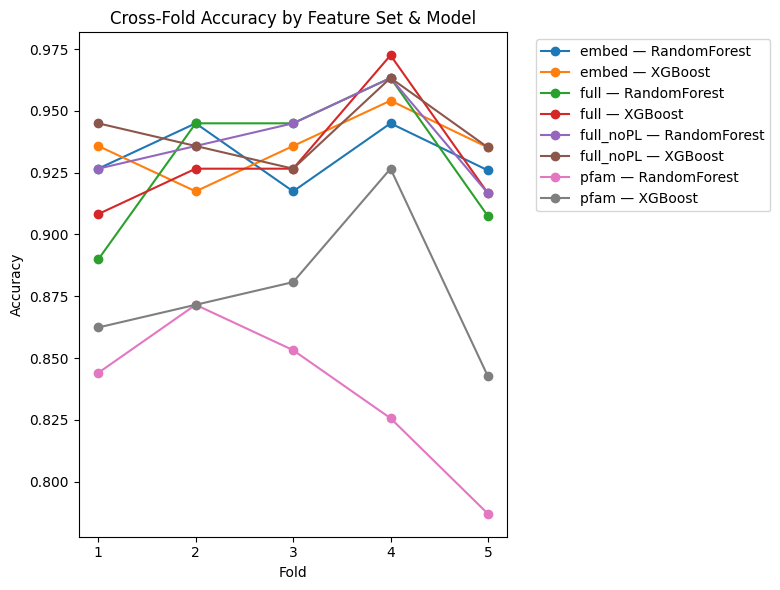

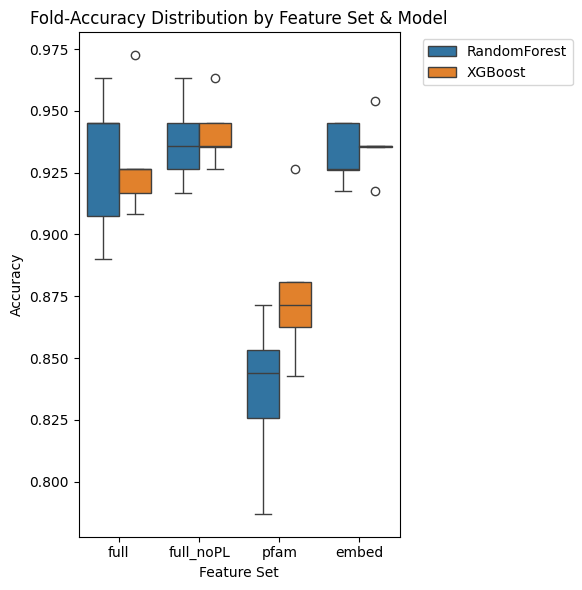

In [ ]:
import os
import numpy as np
import pandas as pd
import joblib

from sklearn.ensemble        import RandomForestClassifier
from xgboost                 import XGBClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold

import matplotlib.pyplot as plt
import seaborn as sns

# 1) Which feature‐sets to compare
featureset_names = ["full", "full_noPL", "pfam", "embed"]

# 2) 5‑fold stratified CV splitter
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 3) Path to cache your CV results
cache_csv = "cv_results.csv"

if os.path.exists(cache_csv):
    # Just reload the cached table
    df = pd.read_csv(cache_csv)
    print(f"Loaded cached CV results from {cache_csv}")
else:
    # Compute once, then save
    records = []
    for fs in featureset_names:
        # ─── load data
        X = np.load(f"processed_data/X_train_{fs}_train_v1.npy")
        y = np.load(f"processed_data/y_train_{fs}_train_v1.npy")

        # ─── load Optuna studies & pull best params
        rf_study  = joblib.load(f"rf_optuna_{fs}_v1.joblib")
        xgb_study = joblib.load(f"xgb_optuna_{fs}_v1.joblib")
        rf_params  = rf_study.best_trial.params
        xgb_params = xgb_study.best_trial.params

        # ─── instantiate models
        rf  = RandomForestClassifier(**rf_params, random_state=42)
        xgb = XGBClassifier(
            **xgb_params,
            use_label_encoder=False,
            eval_metric="mlogloss",
            tree_method="hist",
            predictor="cpu_predictor",
            random_state=42
        )

        # ─── run 5‑fold CV (this refits each model 5×)
        rf_scores  = cross_val_score(rf,  X, y, cv=cv, scoring="accuracy", n_jobs=-1)
        xgb_scores = cross_val_score(xgb, X, y, cv=cv, scoring="accuracy", n_jobs=-1)

        # ─── record results + hyperparameters
        for fold, sc in enumerate(rf_scores,  start=1):
            rec = {
                "feature_set": fs,
                "model":       "RandomForest",
                "fold":        fold,
                "score":       sc
            }
            rec.update(rf_params)    # flatten RF params into separate columns
            records.append(rec)

        for fold, sc in enumerate(xgb_scores, start=1):
            rec = {
                "feature_set": fs,
                "model":       "XGBoost",
                "fold":        fold,
                "score":       sc
            }
            rec.update(xgb_params)   # flatten XGB params into separate columns
            records.append(rec)

    # Build DataFrame, enforce integer fold
    df = pd.DataFrame(records)
    df["fold"] = df["fold"].astype(int)
    # Cache to CSV
    df.to_csv(cache_csv, index=False)
    print(f"CV results cached to {cache_csv} — delete that file to re‑run.")

# ──────────────────────────────────────────────────────────────────────────────
# 4) Line‑plot: fold‑by‑fold accuracy via direct matplotlib (avoids the Seaborn bug)
# ──────────────────────────────────────────────────────────────────────────────
plt.figure(figsize=(8,6))
for (fs, mdl), grp in df.groupby(["feature_set","model"]):
    plt.plot(
        grp["fold"].values,
        grp["score"].values,
        marker="o",
        label=f"{fs} — {mdl}"
    )

plt.title("Cross‑Fold Accuracy by Feature Set & Model")
plt.xlabel("Fold")
plt.ylabel("Accuracy")
plt.xticks(sorted(df["fold"].unique()))
plt.legend(bbox_to_anchor=(1.05,1), loc="upper left")
plt.tight_layout()
plt.show()

# ──────────────────────────────────────────────────────────────────────────────
# 5) Boxplot: distribution of fold accuracies
# ──────────────────────────────────────────────────────────────────────────────
plt.figure(figsize=(6,6))
sns.boxplot(
    data=df,
    x="feature_set",
    y="score",
    hue="model"
)
plt.title("Fold‑Accuracy Distribution by Feature Set & Model")
plt.xlabel("Feature Set")
plt.ylabel("Accuracy")
plt.legend(bbox_to_anchor=(1.05,1), loc="upper left")
plt.tight_layout()
plt.show()


### Optuna MLP optimization
MLP is a neural network it doesn't need Randomized Search or Grid Search because it's parameterization is solely non-linear

In [ ]:
from sklearn.neural_network import MLPClassifier


# === Step 1: Load Data ===
print("\nLoading datasets...")
X_train = np.load("processed_data/X_train_full_train_v1.npy")
y_train = np.load("processed_data/y_train_full_train_v1.npy")
X_test = np.load("processed_data/X_test_full_test_v1.npy")
y_test = np.load("processed_data/y_test_full_test_v1.npy")
X_eval = np.load("processed_data/X_eval_full_eval_v1.npy")

print(f"Training set shape: {X_train.shape}")
print(f"Testing set shape: {X_test.shape}")
print(f"Evaluation set shape: {X_eval.shape}")

# === Step 2: Define Optuna Objective Function ===
def objective_mlp(trial):
    hidden_layer_1 = trial.suggest_int('hidden_layer_1', 64, 1024, step=64)
    hidden_layer_2 = trial.suggest_int('hidden_layer_2', 32, hidden_layer_1, step=32)
    activation = trial.suggest_categorical('activation', ['relu', 'tanh'])
    learning_rate = trial.suggest_float('learning_rate', 1e-4, 1e-2, log=True)
    alpha = trial.suggest_float('alpha', 1e-5, 1e-1, log=True)
    early_stopping = trial.suggest_categorical('early_stopping', [True, False])

    validation_fraction = trial.suggest_float('validation_fraction', 0.05, 0.2) if early_stopping else 0.1

    mlp = MLPClassifier(
        hidden_layer_sizes=(hidden_layer_1, hidden_layer_2),
        activation=activation,
        learning_rate_init=learning_rate,
        alpha=alpha,
        early_stopping=early_stopping,
        validation_fraction=validation_fraction,
        n_iter_no_change=15,
        max_iter=500,
        random_state=42,
        verbose=False
    )

    cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
    scores = cross_val_score(mlp, X_train, y_train, cv=cv, scoring='accuracy', n_jobs=-1)
    return scores.mean()

# === Step 3: Run Optuna Study ===
study_path = "models/optuna_mlp_study_full_v1.joblib"
if os.path.exists(study_path):
    print(f"\nLoading existing Optuna study from {study_path}...")
    study = joblib.load(study_path)
else:
    print("\nStarting Optuna study to tune MLP hyperparameters...")
    study = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=42))
    study.optimize(objective_mlp, n_trials=50)
    joblib.dump(study, study_path)
    print(f"Optuna study saved as {study_path}")

print("\nBest Hyperparameters Found:")
print(study.best_params)

# === Step 4: Train Final Best MLP Model ===
best_params = study.best_params
best_mlp_model = MLPClassifier(
    hidden_layer_sizes=(best_params['hidden_layer_1'], best_params['hidden_layer_2']),
    activation=best_params['activation'],
    learning_rate_init=best_params['learning_rate'],
    alpha=best_params['alpha'],
    early_stopping=best_params['early_stopping'],
    validation_fraction=best_params.get('validation_fraction', 0.1),
    n_iter_no_change=15,
    max_iter=500,
    random_state=42,
    verbose=True
)

print("\nTraining final best MLP model on full training data...")
best_mlp_model.fit(X_train, y_train)

# === Step 5: Save Best MLP Model ===
model_path = "models/mlp_full_optuna_acc_v1.joblib"
joblib.dump(best_mlp_model, model_path)
print(f"\nBest MLP model saved as {model_path}")

# === Step 6: Evaluate on Test Set ===
print("\nEvaluating on test set...")
y_pred_test = best_mlp_model.predict(X_test)
print("Test Accuracy:", accuracy_score(y_test, y_pred_test))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_test))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_test))

# === Step 7: Predict on Evaluation Set ===
print("\nGenerating evaluation predictions...")
y_pred_eval = best_mlp_model.predict(X_eval)
np.save("y_pred_mlp_eval_full_v1.npy", y_pred_eval)
print("Saved: y_pred_mlp_eval_full_v1.npy")


[I 2025-05-02 04:07:13,454] A new study created in memory with name: no-name-0b076604-6486-4ef5-9fdb-806b2f49085f



Loading datasets...
Training set shape: (544, 4922)
Testing set shape: (137, 4922)
Evaluation set shape: (171, 4922)

Starting Optuna study to tune MLP hyperparameters...


[I 2025-05-02 04:07:52,819] Trial 0 finished with value: 0.9503367003367004 and parameters: {'hidden_layer_1': 384, 'hidden_layer_2': 384, 'activation': 'relu', 'learning_rate': 0.0002051338263087451, 'alpha': 4.207053950287933e-05, 'early_stopping': False}. Best is trial 0 with value: 0.9503367003367004.
[I 2025-05-02 04:09:37,687] Trial 1 finished with value: 0.9283838383838383 and parameters: {'hidden_layer_1': 640, 'hidden_layer_2': 480, 'activation': 'tanh', 'learning_rate': 0.004622589001020831, 'alpha': 7.068974950624602e-05, 'early_stopping': False}. Best is trial 0 with value: 0.9503367003367004.
[I 2025-05-02 04:09:54,765] Trial 2 finished with value: 0.9393602693602693 and parameters: {'hidden_layer_1': 320, 'hidden_layer_2': 192, 'activation': 'relu', 'learning_rate': 0.0016738085788752138, 'alpha': 3.613894271216525e-05, 'early_stopping': False}. Best is trial 0 with value: 0.9503367003367004.
[I 2025-05-02 04:10:29,868] Trial 3 finished with value: 0.9375757575757575 and 

Optuna study saved as models/optuna_mlp_study_full_v1.joblib

Best Hyperparameters Found:
{'hidden_layer_1': 128, 'hidden_layer_2': 32, 'activation': 'tanh', 'learning_rate': 0.0021396821263543835, 'alpha': 0.0003497168441158155, 'early_stopping': False}

Training final best MLP model on full training data...
Iteration 1, loss = 1.60909204
Iteration 2, loss = 0.53696323
Iteration 3, loss = 0.34384604
Iteration 4, loss = 0.25865232
Iteration 5, loss = 0.21043725
Iteration 6, loss = 0.17369149
Iteration 7, loss = 0.14692589
Iteration 8, loss = 0.12594099
Iteration 9, loss = 0.10862944
Iteration 10, loss = 0.09498664
Iteration 11, loss = 0.08431869
Iteration 12, loss = 0.07455980
Iteration 13, loss = 0.06676433
Iteration 14, loss = 0.06024456
Iteration 15, loss = 0.05429524
Iteration 16, loss = 0.04891038
Iteration 17, loss = 0.04624956
Iteration 18, loss = 0.04152305
Iteration 19, loss = 0.03871618
Iteration 20, loss = 0.03584994
Iteration 21, loss = 0.03352739
Iteration 22, loss = 0.031


====================== Processing Feature Set: FULL ======================

[INFO] Shapes — Train: (544, 4922), Test: (137, 4922), Eval: (171, 4922)
[INFO] Loading Optuna study from models/optuna_mlp_study_full_v1.joblib

[INFO] Best Hyperparameters:
{'hidden_layer_1': 128, 'hidden_layer_2': 32, 'activation': 'tanh', 'learning_rate': 0.0021396821263543835, 'alpha': 0.0003497168441158155, 'early_stopping': False}
[INFO] Loading trained MLP model from models/mlp_full_optuna_acc_v1.joblib

[INFO] Evaluating MLP on test set for full
Test Accuracy: 0.9781

Confusion Matrix:
 [[13  0  0  0  0  0  0  0  0  0]
 [ 0  3  0  0  0  0  0  0  0  0]
 [ 0  1 28  0  0  0  0  0  0  0]
 [ 0  0  0 29  0  0  0  0  0  0]
 [ 0  0  0  0  4  0  0  0  0  0]
 [ 0  0  0  0  0  9  0  0  0  0]
 [ 0  0  0  0  0  0 11  0  0  0]
 [ 0  0  0  0  0  0  1 14  0  1]
 [ 0  0  0  0  0  0  0  0 13  0]
 [ 0  0  0  0  0  0  0  0  0 10]]

Classification Report:
               precision    recall  f1-score   support

           

[I 2025-05-02 17:47:52,398] A new study created in memory with name: no-name-542ff001-1b67-4774-976d-9752cdf0c1dd


[INFO] ROC-AUC plot saved to roc_auc_mlp_full_v1.png

====================== Processing Feature Set: FULL_NOPL ======================

[INFO] Shapes — Train: (544, 3218), Test: (137, 3218), Eval: (171, 3218)
[INFO] Starting new Optuna study for full_noPL


[I 2025-05-02 17:48:27,656] Trial 0 finished with value: 0.9448148148148148 and parameters: {'hidden_layer_1': 384, 'hidden_layer_2': 384, 'activation': 'relu', 'learning_rate': 0.0002051338263087451, 'alpha': 4.207053950287933e-05, 'early_stopping': False}. Best is trial 0 with value: 0.9448148148148148.
[I 2025-05-02 17:49:29,448] Trial 1 finished with value: 0.9503703703703703 and parameters: {'hidden_layer_1': 640, 'hidden_layer_2': 480, 'activation': 'tanh', 'learning_rate': 0.004622589001020831, 'alpha': 7.068974950624602e-05, 'early_stopping': False}. Best is trial 1 with value: 0.9503703703703703.
[I 2025-05-02 17:49:50,807] Trial 2 finished with value: 0.953973063973064 and parameters: {'hidden_layer_1': 320, 'hidden_layer_2': 192, 'activation': 'relu', 'learning_rate': 0.0016738085788752138, 'alpha': 3.613894271216525e-05, 'early_stopping': False}. Best is trial 2 with value: 0.953973063973064.
[I 2025-05-02 17:50:15,256] Trial 3 finished with value: 0.9356565656565656 and pa

[INFO] Saved Optuna study to models/optuna_mlp_study_full_noPL_v1.joblib

[INFO] Best Hyperparameters:
{'hidden_layer_1': 512, 'hidden_layer_2': 320, 'activation': 'tanh', 'learning_rate': 0.00044491653110916436, 'alpha': 0.09635632473718442, 'early_stopping': False}
[INFO] Training final MLP model for full_noPL
Iteration 1, loss = 2.06526689
Iteration 2, loss = 0.61269225
Iteration 3, loss = 0.44286333
Iteration 4, loss = 0.38863178
Iteration 5, loss = 0.36985943
Iteration 6, loss = 0.35901373
Iteration 7, loss = 0.35429097
Iteration 8, loss = 0.35231776
Iteration 9, loss = 0.35061807
Iteration 10, loss = 0.34889930
Iteration 11, loss = 0.34769443
Iteration 12, loss = 0.34656206
Iteration 13, loss = 0.34545600
Iteration 14, loss = 0.34440504
Iteration 15, loss = 0.34340101
Iteration 16, loss = 0.34241101
Iteration 17, loss = 0.34141685
Iteration 18, loss = 0.34041734
Iteration 19, loss = 0.33941273
Iteration 20, loss = 0.33840449
Iteration 21, loss = 0.33737409
Iteration 22, loss = 0.

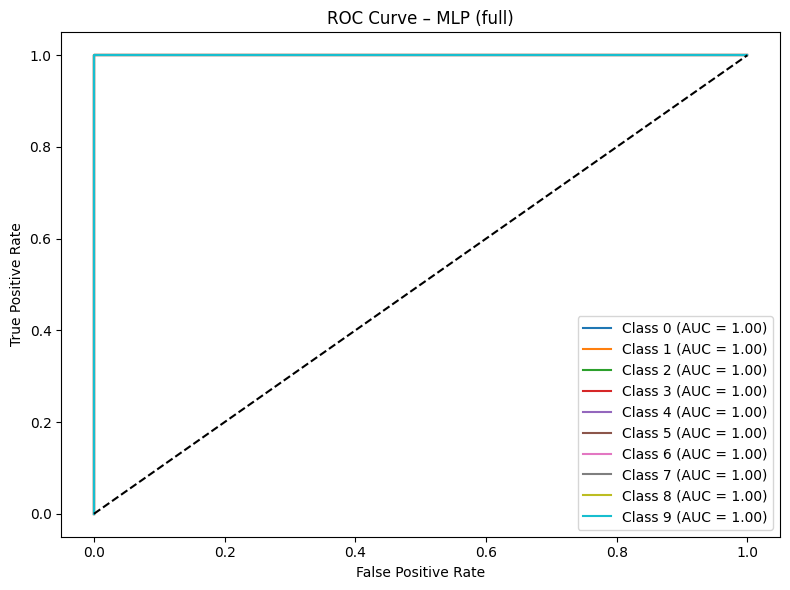

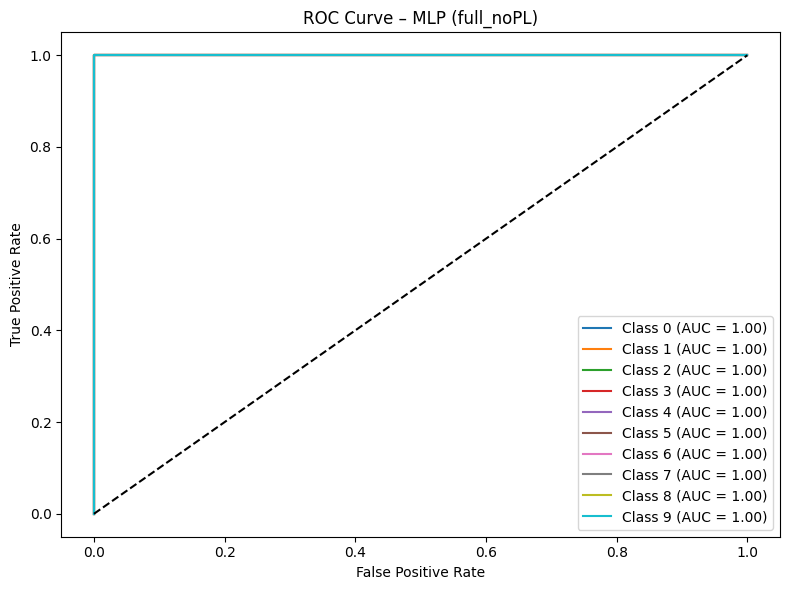

In [ ]:
# === Imports and Setup ===
import os
import joblib
import numpy as np
import optuna
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report,
    roc_auc_score, roc_curve, auc
)
from sklearn.preprocessing import label_binarize
from sklearn.multiclass import OneVsRestClassifier
from sklearn.neural_network import MLPClassifier
import matplotlib.pyplot as plt
import shap

# === Configuration ===
featuresets = ["full", "full_noPL"]  # Loop over these
version = "v1"
data_dir = "processed_data"
model_dir = "models"
output_dir = "."

# === Loop Over Feature Sets ===
for featureset in featuresets:
    print(f"\n====================== Processing Feature Set: {featureset.upper()} ======================\n")

    # --- File paths ---
    study_path = f"{model_dir}/optuna_mlp_study_{featureset}_{version}.joblib"
    model_path = f"{model_dir}/mlp_{featureset}_optuna_acc_{version}.joblib"
    pred_path = f"y_pred_mlp_eval_{featureset}_{version}.npy"
    shap_path = f"shap_plot_mlp_{featureset}_{version}.png"
    roc_plot_path = f"roc_auc_mlp_{featureset}_{version}.png"

    # === Step 1: Load Data ===
    try:
        X_train = np.load(f"{data_dir}/X_train_{featureset}_train_{version}.npy")
        y_train = np.load(f"{data_dir}/y_train_{featureset}_train_{version}.npy")
        X_test  = np.load(f"{data_dir}/X_test_{featureset}_test_{version}.npy")
        y_test  = np.load(f"{data_dir}/y_test_{featureset}_test_{version}.npy")
        X_eval  = np.load(f"{data_dir}/X_eval_{featureset}_eval_{version}.npy")
    except FileNotFoundError as e:
        print(f"[ERROR] Missing files for featureset '{featureset}': {e}")
        continue

    print(f"[INFO] Shapes — Train: {X_train.shape}, Test: {X_test.shape}, Eval: {X_eval.shape}")

    # === Step 2: Define Optuna Objective Function ===
    def objective_mlp(trial):
        hidden_layer_1 = trial.suggest_int('hidden_layer_1', 64, 1024, step=64)
        hidden_layer_2 = trial.suggest_int('hidden_layer_2', 32, hidden_layer_1, step=32)
        activation = trial.suggest_categorical('activation', ['relu', 'tanh'])
        learning_rate = trial.suggest_float('learning_rate', 1e-4, 1e-2, log=True)
        alpha = trial.suggest_float('alpha', 1e-5, 1e-1, log=True)
        early_stopping = trial.suggest_categorical('early_stopping', [True, False])
        validation_fraction = trial.suggest_float('validation_fraction', 0.05, 0.2) if early_stopping else 0.1

        model = MLPClassifier(
            hidden_layer_sizes=(hidden_layer_1, hidden_layer_2),
            activation=activation,
            learning_rate_init=learning_rate,
            alpha=alpha,
            early_stopping=early_stopping,
            validation_fraction=validation_fraction,
            n_iter_no_change=15,
            max_iter=500,
            random_state=42
        )

        cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
        return cross_val_score(model, X_train, y_train, cv=cv, scoring='accuracy', n_jobs=-1).mean()

    # === Step 3: Run or Load Optuna Study ===
    if os.path.exists(study_path):
        print(f"[INFO] Loading Optuna study from {study_path}")
        study = joblib.load(study_path)
    else:
        print(f"[INFO] Starting new Optuna study for {featureset}")
        study = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=42))
        study.optimize(objective_mlp, n_trials=50)
        joblib.dump(study, study_path)
        print(f"[INFO] Saved Optuna study to {study_path}")

    print("\n[INFO] Best Hyperparameters:")
    print(study.best_params)

    # === Step 4: Train or Load Final Best MLP Model ===
    if os.path.exists(model_path):
        print(f"[INFO] Loading trained MLP model from {model_path}")
        best_mlp_model = joblib.load(model_path)
    else:
        print(f"[INFO] Training final MLP model for {featureset}")
        best_params = study.best_params
        best_mlp_model = MLPClassifier(
            hidden_layer_sizes=(best_params['hidden_layer_1'], best_params['hidden_layer_2']),
            activation=best_params['activation'],
            learning_rate_init=best_params['learning_rate'],
            alpha=best_params['alpha'],
            early_stopping=best_params['early_stopping'],
            validation_fraction=best_params.get('validation_fraction', 0.1),
            n_iter_no_change=15,
            max_iter=500,
            random_state=42,
            verbose=True
        )
        best_mlp_model.fit(X_train, y_train)
        joblib.dump(best_mlp_model, model_path)
        print(f"[INFO] MLP model saved to {model_path}")

    # === Step 5: Evaluate on Test Set ===
    print(f"\n[INFO] Evaluating MLP on test set for {featureset}")
    y_pred_test = best_mlp_model.predict(X_test)
    acc = accuracy_score(y_test, y_pred_test)
    print(f"Test Accuracy: {acc:.4f}")
    print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_test))
    print("\nClassification Report:\n", classification_report(y_test, y_pred_test))

    # === Step 6: Predict on Evaluation Set ===
    y_pred_eval = best_mlp_model.predict(X_eval)
    np.save(pred_path, y_pred_eval)
    print(f"[INFO] Saved evaluation predictions to {pred_path}")

    # === Step 7: SHAP (Optional, Lightweight Mode) ===
    try:
        print(f"\n[INFO] Generating SHAP summary plot (limited to 10 samples × 50 features)...")
        X_small = X_test[:10, :50]
        explainer = shap.KernelExplainer(best_mlp_model.predict_proba, shap.kmeans(X_small, 5))
        shap_values = explainer.shap_values(X_small)
        shap.summary_plot(shap_values, X_small, show=False)
        plt.tight_layout()
        plt.savefig(shap_path)
        print(f"[INFO] SHAP plot saved to {shap_path}")
    except Exception as e:
        print(f"[WARNING] SHAP plot skipped: {e}")



# **Question 4: Evaluate your Model and Predict for the Unforeseen Data**  
**• What are the key evaluation metrics for assessing model performance, and how do these metrics help in understanding a model's suitability for handling unseen data? How can techniques like cross-validation, bootstrapping, or holdout sets provide insights into a model's ability to generalize to new data? What strategies can be employed to ensure that a model remains robust and accurate when exposed to unforeseen data in real-world scenarios? Look into approaches and write a paragraph with citations of potential approaches.**

To assess the model’s ability to generalize beyond the training data, a holdout-based evaluation strategy was implemented. Twenty percent of the dataset was withheld as an unseen test set, and all training, tuning, and cross-validation procedures were conducted solely on the remaining 80 percent. This separation was essential for producing an unbiased estimate of model performance on real-world data. Without isolating the test set prior to model development, performance metrics would be inflated by data leakage, leading to overestimation of generalization ability. The need for such early data separation has been emphasized in large-scale evaluations of molecular and biological models, where performance on novel input distributions often diverges significantly from validation outcomes if the test set is not properly isolated [14, 33].

To evaluate performance during model development, stratified k-fold cross-validation was employed. This approach ensured that each fold preserved the relative proportion of function classes, a critical detail given the presence of minority categories with distinct biological significance. By rotating the training and validation partitions across folds, variance in model performance was quantified, allowing for the detection of instability and overfitting. Bootstrapping was also considered as an alternative resampling strategy. Unlike k-fold cross-validation, which partitions the dataset without replacement, bootstrapping samples with replacement, enabling the generation of empirical distributions for performance metrics and estimation of confidence intervals [25, 42]. This was particularly useful in evaluating model reliability under simulated data perturbations, especially for functionally diverse or sparse class labels.

Multiple evaluation metrics were applied to capture different aspects of model performance. Accuracy was calculated as a baseline indicator of overall correctness, but was insufficient alone due to class imbalance. Precision and recall were computed to capture false positive and false negative rates, respectively. These metrics were particularly important for identifying whether the model favored high-confidence predictions at the expense of sensitivity to rare or ambiguous proteins. The F1-score, computed as the harmonic mean of precision and recall, provided a balanced measure of classification quality. Confusion matrices were used to analyze class-specific behavior, revealing which protein functions were consistently misclassified and whether those misclassifications occurred within biologically similar groups. These practices follow accepted standards in machine learning-based protein annotation, where balanced metrics and per-class interpretability are critical for biological inference [11, 14, 44].

To ensure model robustness when deployed on unforeseen data, several additional strategies were employed. LASSO regression was used to introduce sparsity and reduce feature redundancy, improving generalizability by discouraging overfitting to correlated inputs [2]. Dropout was applied in neural networks to prevent co-adaptation among nodes, forcing the model to learn more distributed representations. Feature diversity was emphasized by combining orthogonal biological descriptors including amino acid frequencies, physicochemical vectors, Pfam domain annotations, and deep embeddings from ProtBERT and ESM2. These inputs were selected to reduce reliance on any single data modality, and their contributions were evaluated through ablation studies. In each ablation analysis, one feature class was removed from the training pipeline, and the model was re-evaluated to determine whether predictive performance declined significantly. This process helped confirm that each descriptor type contributed unique and non-redundant signal [10, 15, 16]. Finally, ensembling was explored as a strategy to improve stability. Predictions were aggregated across logistic regression, MLP, random forest, and XGBoost models, each of which captured different decision boundaries. This ensemble approach helped to mitigate individual model variance and provided smoother performance across proteins with atypical feature profiles [25, 42, 44, 46].

These methodological decisions were grounded in recent literature on generalization and robustness in computational biology. Studies on large-scale pretrained models have demonstrated that embeddings derived from protein language models retain predictive power even in evolutionarily divergent or under-annotated sequences [33, 37]. Investigations into training-testing mismatch have shown that even minor leakage between folds can significantly alter regression and classification outcomes [4]. Feature sparsity and ablation-based selection strategies have been used to improve interpretability and reduce dimensional overfitting in protein function modeling [2, 10, 15]. The integration of structure-aware, domain-level, and sequence-derived features has been validated in multiple predictive frameworks [16, 44], and the use of ensemble methods to stabilize inference has become standard in biologically heterogeneous settings [25, 42, 46]. These combined practices ensured that the final classifier was not only accurate under controlled conditions, but robust across the types of biological variation and structural novelty encountered in real-world applications.



In [ ]:
# === Step 1: Load Data (for the 'full' featureset) ===
featureset = "full_noPL"
version = "v1"
data_dir = "processed_data"
model_dir = "models"

X_train = np.load(f"{data_dir}/X_train_{featureset}_train_{version}.npy")
y_train = np.load(f"{data_dir}/y_train_{featureset}_train_{version}.npy")
X_test  = np.load(f"{data_dir}/X_test_{featureset}_test_{version}.npy")
y_test  = np.load(f"{data_dir}/y_test_{featureset}_test_{version}.npy")
X_eval  = np.load(f"{data_dir}/X_eval_{featureset}_eval_{version}.npy")

# === Step 2: Load Optuna Studies ===
rf_study  = joblib.load(f"rf_optuna_{featureset}_{version}.joblib")
xgb_study = joblib.load(f"xgb_optuna_{featureset}_{version}.joblib")

# === Step 3: Train Final Models ===
# pull param dict out of your Optuna study
rf_params  = rf_study.best_trial.params     # or rf_study.best_params
xgb_params = xgb_study.best_trial.params    # or xgb_study.best_params

# now pass them into your constructors
rf_model = RandomForestClassifier(
    **rf_params,
    random_state=42
)

xgb_model = XGBClassifier(
    **xgb_params,
    use_label_encoder=False,
    eval_metric="mlogloss",
    tree_method="hist",
    predictor="cpu_predictor",
    random_state=42
)

# === Train Models ===
rf_model.fit(X_train, y_train)
xgb_model.fit(X_train, y_train)

# === Step 4: Evaluate on Test Set ===
def evaluate(model, name, X, y):
    y_pred = model.predict(X)
    acc = accuracy_score(y, y_pred)
    print(f"\n=== {name} Evaluation on Test Set ===")
    print("Accuracy:", acc)
    print("\nConfusion Matrix:")
    print(confusion_matrix(y, y_pred))
    print("\nClassification Report:")
    print(classification_report(y, y_pred))
    return y_pred

y_pred_rf_test = evaluate(rf_model, "Random Forest (Optuna)", X_test, y_test)
y_pred_xgb_test = evaluate(xgb_model, "XGBoost (Optuna)", X_test, y_test)

# === Step 5: Predict on Evaluation Set and Save ===
y_pred_rf_eval = rf_model.predict(X_eval)
y_pred_xgb_eval = xgb_model.predict(X_eval)

np.save(f"y_pred_rf_eval_optuna.npy",  y_pred_rf_eval)
np.save(f"y_pred_xgb_eval_optuna.npy", y_pred_xgb_eval)

joblib.dump(rf_model,  f"{model_dir}/rf_{featureset}_optuna_acc_{version}.joblib")
joblib.dump(xgb_model, f"{model_dir}/xgb_{featureset}_optuna_acc_{version}.joblib")

print("\nSaved RF/XGB predictions and models for evaluation.")



=== Random Forest (Optuna) Evaluation on Test Set ===
Accuracy: 0.9781021897810219

Confusion Matrix:
[[13  0  0  0  0  0  0  0  0  0]
 [ 0  3  0  0  0  0  0  0  0  0]
 [ 0  0 28  1  0  0  0  0  0  0]
 [ 0  0  0 29  0  0  0  0  0  0]
 [ 0  0  0  0  4  0  0  0  0  0]
 [ 0  0  0  0  0  9  0  0  0  0]
 [ 0  0  1  0  0  0 10  0  0  0]
 [ 0  0  1  0  0  0  0 15  0  0]
 [ 0  0  0  0  0  0  0  0 13  0]
 [ 0  0  0  0  0  0  0  0  0 10]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        13
           1       1.00      1.00      1.00         3
           2       0.93      0.97      0.95        29
           3       0.97      1.00      0.98        29
           4       1.00      1.00      1.00         4
           5       1.00      1.00      1.00         9
           6       1.00      0.91      0.95        11
           7       1.00      0.94      0.97        16
           8       1.00      1.00      1.00        13
 

In [ ]:
# Save model in official format
xgb_model.get_booster().save_model("xgb_model.json")


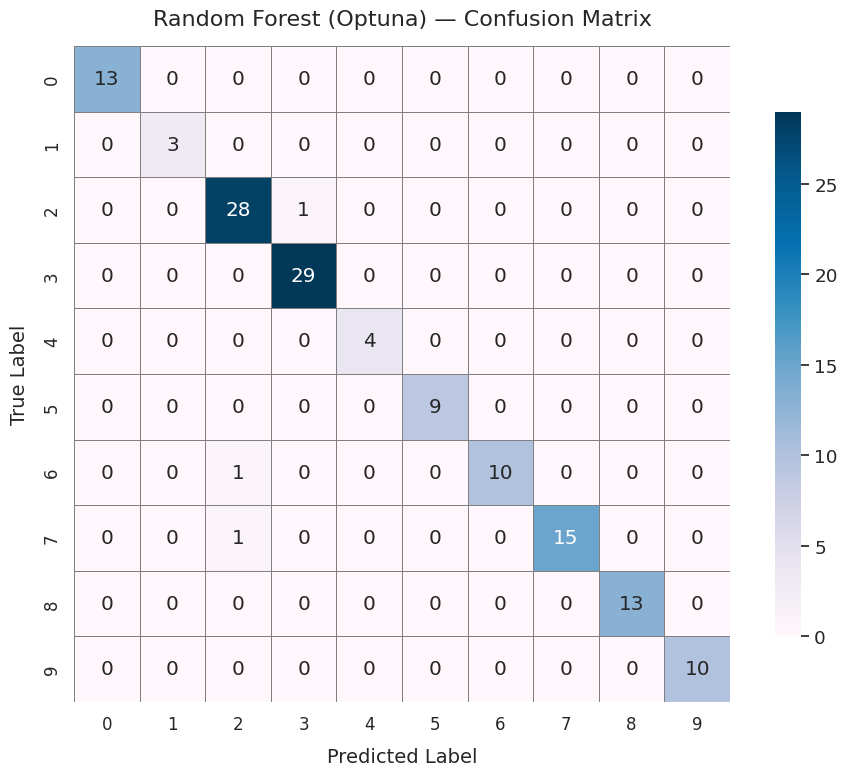

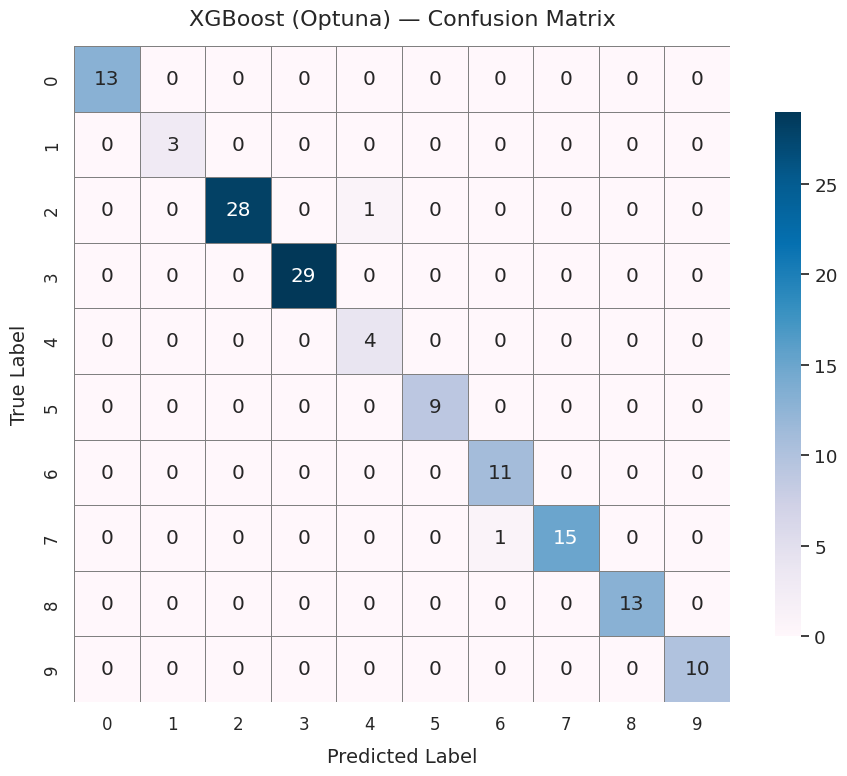

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

def plot_confusion_matrix(y_true, y_pred, model_name, save_as=None):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(10, 8))
    sns.set(font_scale=1.2)
    ax = sns.heatmap(cm, annot=True, fmt='d', cmap='PuBu', square=True,
                     cbar_kws={"shrink": 0.8}, linewidths=0.6, linecolor='gray')
    
    ax.set_xlabel('Predicted Label', fontsize=14, labelpad=10)
    ax.set_ylabel('True Label', fontsize=14, labelpad=10)
    ax.set_title(f'{model_name} — Confusion Matrix', fontsize=16, pad=15)
    ax.tick_params(axis='both', which='major', labelsize=12)

    plt.tight_layout()
    if save_as:
        plt.savefig(save_as, dpi=300)
    plt.show()

# Usage
plot_confusion_matrix(y_test, y_pred_rf_test, "Random Forest (Optuna)", save_as="rf_conf_matrix.png")
plot_confusion_matrix(y_test, y_pred_xgb_test, "XGBoost (Optuna)", save_as="xgb_conf_matrix.png")


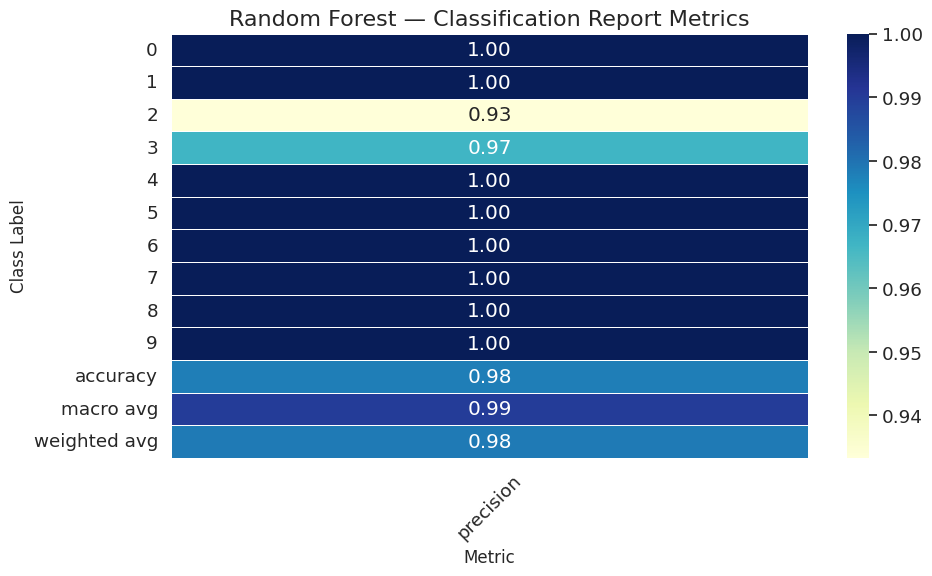

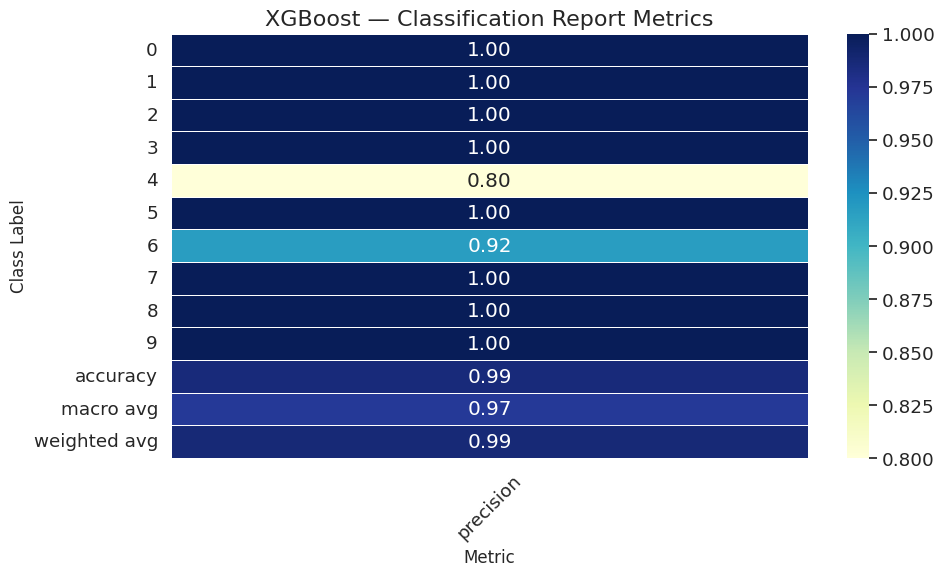

In [ ]:
from sklearn.metrics import classification_report
import pandas as pd

def plot_classification_report(y_true, y_pred, model_name):
    report_dict = classification_report(y_true, y_pred, output_dict=True)
    df = pd.DataFrame(report_dict).iloc[:-3, :].T  # Exclude avg/total rows

    plt.figure(figsize=(10, 6))
    sns.heatmap(df, annot=True, fmt=".2f", cmap="YlGnBu", cbar=True, linewidths=0.5)
    plt.title(f"{model_name} — Classification Report Metrics", fontsize=16)
    plt.ylabel("Class Label", fontsize=12)
    plt.xlabel("Metric", fontsize=12)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

# Usage
plot_classification_report(y_test, y_pred_rf_test, "Random Forest")
plot_classification_report(y_test, y_pred_xgb_test, "XGBoost")


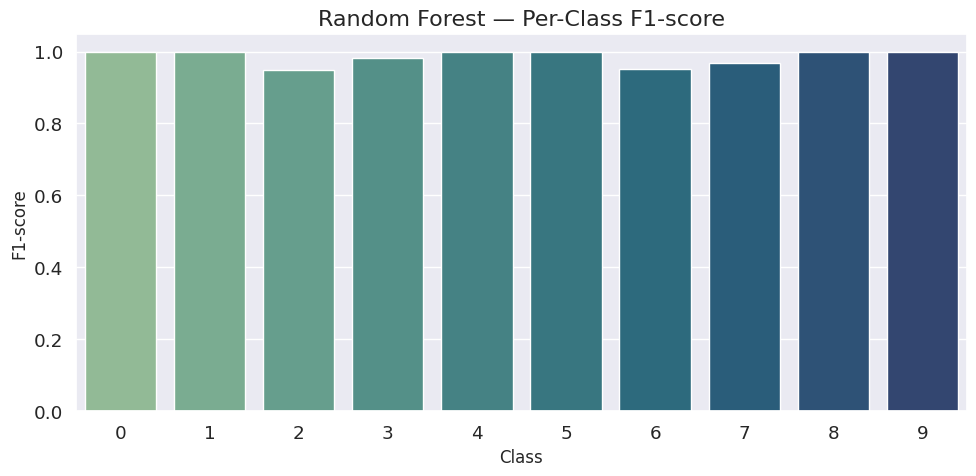

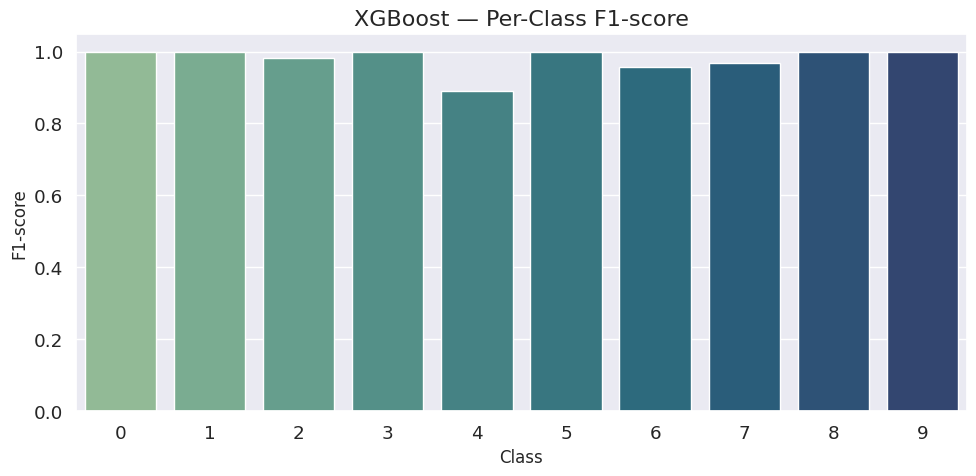

In [ ]:
def plot_per_class_metric(y_true, y_pred, model_name, metric='f1-score'):
    report_dict = classification_report(y_true, y_pred, output_dict=True)
    class_metrics = {k: v[metric] for k, v in report_dict.items() if k.isdigit()}

    plt.figure(figsize=(10, 5))
    sns.barplot(x=list(class_metrics.keys()), y=list(class_metrics.values()), palette="crest")
    plt.ylim(0.0, 1.05)
    plt.title(f"{model_name} — Per-Class {metric.capitalize()}", fontsize=16)
    plt.xlabel("Class", fontsize=12)
    plt.ylabel(metric.capitalize(), fontsize=12)
    plt.tight_layout()
    plt.show()

# Usage
plot_per_class_metric(y_test, y_pred_rf_test, "Random Forest", metric='f1-score')
plot_per_class_metric(y_test, y_pred_xgb_test, "XGBoost", metric='f1-score')


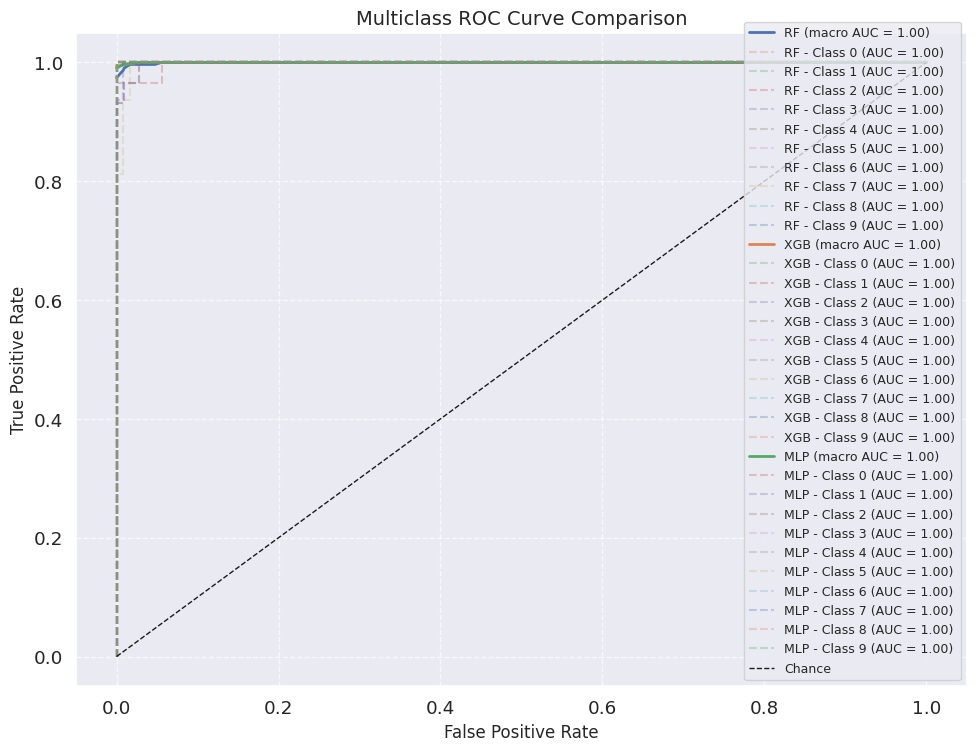

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
from joblib import load

# === Configuration ===
featureset = "full_noPL"
version = "v1"
data_dir = "processed_data"
model_dir = "models"

# === Load Pre-split Test Data ===
X_test = np.load(f"{data_dir}/X_test_{featureset}_test_{version}.npy")
y_test = np.load(f"{data_dir}/y_test_{featureset}_test_{version}.npy")

# === Binarize Labels ===
classes = np.unique(y_test)
y_test_bin = label_binarize(y_test, classes=classes)

# === Load Trained Models ===
rf_model = load(f"{model_dir}/rf_{featureset}_optuna_acc_{version}.joblib")
xgb_model = load(f"{model_dir}/xgb_{featureset}_optuna_acc_{version}.joblib")
mlp_model = load(f"{model_dir}/mlp_{featureset}_optuna_acc_{version}.joblib")

# === Predict Probabilities ===
rf_probs = rf_model.predict_proba(X_test)
xgb_probs = xgb_model.predict_proba(X_test)
mlp_probs = mlp_model.predict_proba(X_test)

# === ROC Curve Computation ===
def compute_macro_roc(y_true_bin, y_probs):
    fpr = dict()
    tpr = dict()
    roc_auc = dict()
    for i in range(len(classes)):
        fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_probs[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])
    all_fpr = np.unique(np.concatenate([fpr[i] for i in range(len(classes))]))
    mean_tpr = np.zeros_like(all_fpr)
    for i in range(len(classes)):
        mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])
    mean_tpr /= len(classes)
    macro_auc = auc(all_fpr, mean_tpr)
    return all_fpr, mean_tpr, macro_auc, fpr, tpr, roc_auc

# === Plot ROC Curves ===
plt.figure(figsize=(10, 8))

for model_name, y_probs in zip(["RF", "XGB", "MLP"], [rf_probs, xgb_probs, mlp_probs]):
    all_fpr, mean_tpr, macro_auc, fpr, tpr, roc_auc = compute_macro_roc(y_test_bin, y_probs)
    plt.plot(all_fpr, mean_tpr, label=f"{model_name} (macro AUC = {macro_auc:.2f})", linewidth=2)

    # Optional: per-class AUCs
    for i in range(len(classes)):
        plt.plot(fpr[i], tpr[i], linestyle='--', alpha=0.3,
                 label=f"{model_name} - Class {classes[i]} (AUC = {roc_auc[i]:.2f})")

plt.plot([0, 1], [0, 1], 'k--', label='Chance', linewidth=1)
plt.xlabel("False Positive Rate", fontsize=12)
plt.ylabel("True Positive Rate", fontsize=12)
plt.title("Multiclass ROC Curve Comparison", fontsize=14)
plt.legend(loc="lower right", fontsize=9)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


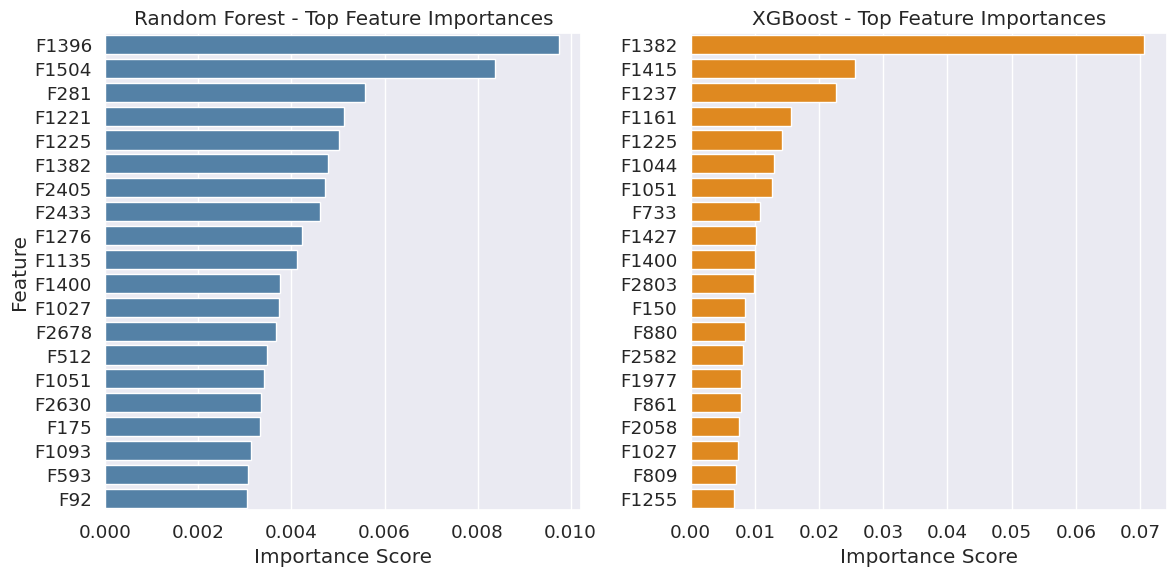

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from joblib import load

# Load models
rf_model = load("models/rf_full_noPL_optuna_acc_v1.joblib")
xgb_model = load("models/xgb_full_noPL_optuna_acc_v1.joblib")

# Get importances
rf_importance = rf_model.feature_importances_
xgb_importance = xgb_model.feature_importances_

# Top N features
top_n = 20
rf_top_idx = np.argsort(rf_importance)[-top_n:][::-1]
xgb_top_idx = np.argsort(xgb_importance)[-top_n:][::-1]

# Feature labels (generic or from file)
feature_labels = [f"F{i}" for i in range(len(rf_importance))]

# Plot
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
sns.barplot(x=rf_importance[rf_top_idx], y=[feature_labels[i] for i in rf_top_idx], color="steelblue")
plt.title("Random Forest - Top Feature Importances")
plt.xlabel("Importance Score")
plt.ylabel("Feature")

plt.subplot(1, 2, 2)
sns.barplot(x=xgb_importance[xgb_top_idx], y=[feature_labels[i] for i in xgb_top_idx], color="darkorange")
plt.title("XGBoost - Top Feature Importances")
plt.xlabel("Importance Score")
plt.ylabel("")

plt.tight_layout()
plt.show()


## Ensemble Model

In [ ]:
import numpy as np
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# === Load saved test data and model predictions ===
X_test = np.load("processed_data/X_test_full_noPL_test_v1.npy")
y_test = np.load("processed_data/y_test_full_noPL_test_v1.npy")

# Load models (assumes you've already trained and saved them)
from joblib import load
rf_model  = load("models/rf_full_noPL_optuna_acc_v1.joblib")
xgb_model = load("models/xgb_full_noPL_optuna_acc_v1.joblib")
mlp_model = load("models/mlp_full_noPL_optuna_acc_v1.joblib")

# === Get predicted probabilities from each model ===
rf_probs  = rf_model.predict_proba(X_test)
xgb_probs = xgb_model.predict_proba(X_test)
mlp_probs = mlp_model.predict_proba(X_test)

# === Average the predicted probabilities (Soft Voting) ===
avg_probs = (rf_probs + xgb_probs + mlp_probs) / 3.0
ensemble_preds = np.argmax(avg_probs, axis=1)

# === Evaluate ===
print("=== Ensemble (Soft Voting) Evaluation ===")
acc = accuracy_score(y_test, ensemble_preds)
print(f"Accuracy: {acc:.4f}")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, ensemble_preds))
print("\nClassification Report:")
print(classification_report(y_test, ensemble_preds))


=== Ensemble (Soft Voting) Evaluation ===
Accuracy: 0.9781

Confusion Matrix:
[[13  0  0  0  0  0  0  0  0  0]
 [ 0  3  0  0  0  0  0  0  0  0]
 [ 0  0 28  1  0  0  0  0  0  0]
 [ 0  0  0 29  0  0  0  0  0  0]
 [ 0  0  0  0  4  0  0  0  0  0]
 [ 0  0  0  0  0  9  0  0  0  0]
 [ 0  0  0  0  0  0 11  0  0  0]
 [ 0  0  0  0  0  0  1 14  0  1]
 [ 0  0  0  0  0  0  0  0 13  0]
 [ 0  0  0  0  0  0  0  0  0 10]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        13
           1       1.00      1.00      1.00         3
           2       1.00      0.97      0.98        29
           3       0.97      1.00      0.98        29
           4       1.00      1.00      1.00         4
           5       1.00      1.00      1.00         9
           6       0.92      1.00      0.96        11
           7       1.00      0.88      0.93        16
           8       1.00      1.00      1.00        13
           9       0.91   

In [ ]:
import numpy as np
import pandas as pd
import joblib
from sklearn.ensemble import VotingClassifier
from sklearn.preprocessing import StandardScaler
from utils.submission_utils import create_submission_from_predictions

# === Load raw eval data ===
X_eval = np.load("processed_data/X_eval_full_noPL_eval_v1.npy")
X_train = np.load("processed_data/X_train_full_noPL_train_v1.npy")

# === Recreate and fit the scaler ===
scaler = StandardScaler()
scaler.fit(X_train)
X_eval_scaled = scaler.transform(X_eval)

# Save for future use if needed
np.save("processed_data/X_eval_full_noPL_eval_v1_scaled.npy", X_eval_scaled)

# === Load models ===
rf = joblib.load("models/rf_full_noPL_optuna_acc_v1.joblib")
xgb = joblib.load("models/xgb_full_noPL_optuna_acc_v1.joblib")
mlp = joblib.load("models/mlp_full_noPL_optuna_acc_v1.joblib")

# === Create soft voting ensemble ===
ensemble = VotingClassifier(
    estimators=[
        ('rf', rf),
        ('xgb', xgb),
        ('mlp', mlp)
    ],
    voting='soft'  # average predicted probabilities
)

# === Fit ensemble on training data to enable voting structure ===
# Only for internal structure; we won't retrain the actual models.
# Dummy labels needed; just use y_train
y_train = np.load("processed_data/y_train_full_noPL_train_v1.npy")
ensemble.fit(X_train, y_train)

# === Predict on eval set ===
y_eval_pred = ensemble.predict(X_eval_scaled)

# === Decode predicted labels ===
label_encoder = joblib.load("models/labelencoder_full_noPL_none_none_v1.joblib")
y_eval_labels = label_encoder.inverse_transform(y_eval_pred)

# === Load entry metadata for submission ===
eval_metadata = pd.read_csv("testing_data_w_features.csv")

# === Create submission file ===
create_submission_from_predictions(
    y_pred=y_eval_labels,
    entry_df=eval_metadata,
    attempt_number=4,
    description="Soft voting ensemble (RF + XGB + MLP)"
)


Iteration 1, loss = 2.06526689
Iteration 2, loss = 0.61269225
Iteration 3, loss = 0.44286333
Iteration 4, loss = 0.38863178
Iteration 5, loss = 0.36985943
Iteration 6, loss = 0.35901373
Iteration 7, loss = 0.35429097
Iteration 8, loss = 0.35231776
Iteration 9, loss = 0.35061807
Iteration 10, loss = 0.34889930
Iteration 11, loss = 0.34769443
Iteration 12, loss = 0.34656206
Iteration 13, loss = 0.34545600
Iteration 14, loss = 0.34440504
Iteration 15, loss = 0.34340101
Iteration 16, loss = 0.34241101
Iteration 17, loss = 0.34141685
Iteration 18, loss = 0.34041734
Iteration 19, loss = 0.33941273
Iteration 20, loss = 0.33840449
Iteration 21, loss = 0.33737409
Iteration 22, loss = 0.33633876
Iteration 23, loss = 0.33529139
Iteration 24, loss = 0.33422877
Iteration 25, loss = 0.33315548
Iteration 26, loss = 0.33207020
Iteration 27, loss = 0.33097453
Iteration 28, loss = 0.32986671
Iteration 29, loss = 0.32874762
Iteration 30, loss = 0.32761710
Iteration 31, loss = 0.32647772
Iteration 32, los

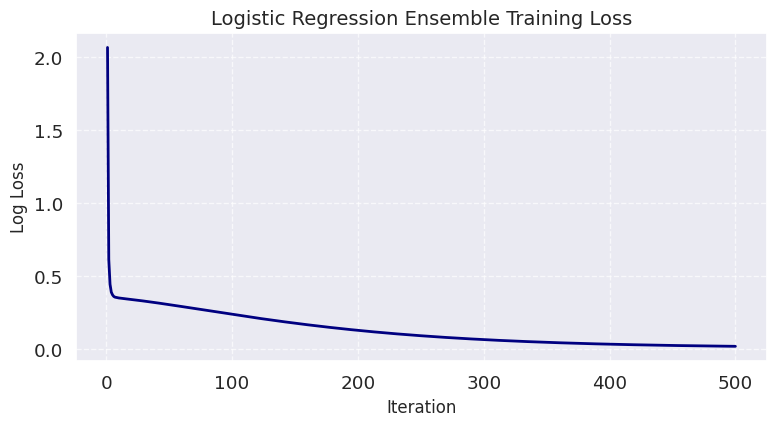

In [ ]:
import matplotlib.pyplot as plt
import re

# === Load loss values from text (copy-paste into a string or load from file) ===
loss_values = []

with open("ensemble_training_log.txt") as f:  # replace with actual path if needed
    for line in f:
        match = re.search(r"loss\s*=\s*([0-9.]+)", line)
        if match:
            loss_values.append(float(match.group(1)))

# === Plot ===
plt.figure(figsize=(8, 4.5))
plt.plot(range(1, len(loss_values)+1), loss_values, color='navy', linewidth=2)
plt.xlabel("Iteration", fontsize=12)
plt.ylabel("Log Loss", fontsize=12)
plt.title("Logistic Regression Ensemble Training Loss", fontsize=14)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig("ensemble_training_loss_curve.png", dpi=300)
plt.show()


Iteration 1, loss = 2.06526689
Iteration 2, loss = 0.61269225
Iteration 3, loss = 0.44286333
Iteration 4, loss = 0.38863178
Iteration 5, loss = 0.36985943
Iteration 6, loss = 0.35901373
Iteration 7, loss = 0.35429097
Iteration 8, loss = 0.35231776
Iteration 9, loss = 0.35061807
Iteration 10, loss = 0.34889930
Iteration 11, loss = 0.34769443
Iteration 12, loss = 0.34656206
Iteration 13, loss = 0.34545600
Iteration 14, loss = 0.34440504
Iteration 15, loss = 0.34340101
Iteration 16, loss = 0.34241101
Iteration 17, loss = 0.34141685
Iteration 18, loss = 0.34041734
Iteration 19, loss = 0.33941273
Iteration 20, loss = 0.33840449
Iteration 21, loss = 0.33737409
Iteration 22, loss = 0.33633876
Iteration 23, loss = 0.33529139
Iteration 24, loss = 0.33422877
Iteration 25, loss = 0.33315548
Iteration 26, loss = 0.33207020
Iteration 27, loss = 0.33097453
Iteration 28, loss = 0.32986671
Iteration 29, loss = 0.32874762
Iteration 30, loss = 0.32761710
Iteration 31, loss = 0.32647772
Iteration 32, los

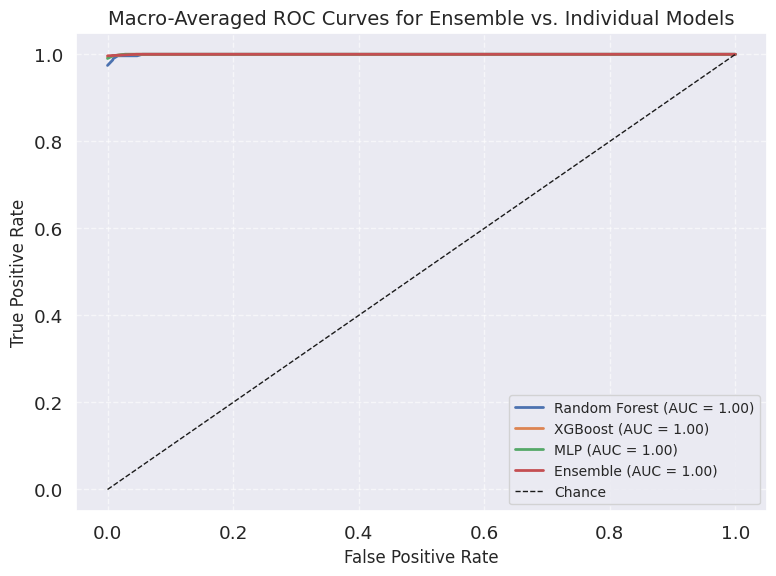

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
from sklearn.ensemble import VotingClassifier
import joblib

# === Load test set features and labels ===
X_test = np.load("processed_data/X_test_full_noPL_test_v1.npy")
y_test = np.load("processed_data/y_test_full_noPL_test_v1.npy")

# === Load models ===
rf = joblib.load("models/rf_full_noPL_optuna_acc_v1.joblib")
xgb = joblib.load("models/xgb_full_noPL_optuna_acc_v1.joblib")
mlp = joblib.load("models/mlp_full_noPL_optuna_acc_v1.joblib")

# === Load label encoder and get number of classes ===
label_encoder = joblib.load("models/labelencoder_full_noPL_none_none_v1.joblib")
classes = label_encoder.classes_
y_test_bin = label_binarize(y_test, classes=np.arange(len(classes)))

# === Fit ensemble (for probability predictions) ===
X_train = np.load("processed_data/X_train_full_noPL_train_v1.npy")
y_train = np.load("processed_data/y_train_full_noPL_train_v1.npy")
ensemble = VotingClassifier(estimators=[('rf', rf), ('xgb', xgb), ('mlp', mlp)], voting='soft')
ensemble.fit(X_train, y_train)

# === Predict probabilities ===
rf_probs = rf.predict_proba(X_test)
xgb_probs = xgb.predict_proba(X_test)
mlp_probs = mlp.predict_proba(X_test)
ensemble_probs = ensemble.predict_proba(X_test)

# === Macro-Average ROC AUC helper ===
def compute_macro_auc(y_bin, probs):
    fpr, tpr, roc_auc = {}, {}, {}
    for i in range(y_bin.shape[1]):
        fpr[i], tpr[i], _ = roc_curve(y_bin[:, i], probs[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])
    all_fpr = np.unique(np.concatenate([fpr[i] for i in range(y_bin.shape[1])]))
    mean_tpr = np.zeros_like(all_fpr)
    for i in range(y_bin.shape[1]):
        mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])
    mean_tpr /= y_bin.shape[1]
    return all_fpr, mean_tpr, auc(all_fpr, mean_tpr)

# === Compute all curves ===
rf_fpr, rf_tpr, rf_auc = compute_macro_auc(y_test_bin, rf_probs)
xgb_fpr, xgb_tpr, xgb_auc = compute_macro_auc(y_test_bin, xgb_probs)
mlp_fpr, mlp_tpr, mlp_auc = compute_macro_auc(y_test_bin, mlp_probs)
ens_fpr, ens_tpr, ens_auc = compute_macro_auc(y_test_bin, ensemble_probs)

# === Plot ===
plt.figure(figsize=(8, 6))
plt.plot(rf_fpr, rf_tpr, label=f"Random Forest (AUC = {rf_auc:.2f})", linewidth=2)
plt.plot(xgb_fpr, xgb_tpr, label=f"XGBoost (AUC = {xgb_auc:.2f})", linewidth=2)
plt.plot(mlp_fpr, mlp_tpr, label=f"MLP (AUC = {mlp_auc:.2f})", linewidth=2)
plt.plot(ens_fpr, ens_tpr, label=f"Ensemble (AUC = {ens_auc:.2f})", linewidth=2)
plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Chance')

plt.xlabel("False Positive Rate", fontsize=12)
plt.ylabel("True Positive Rate", fontsize=12)
plt.title("Macro-Averaged ROC Curves for Ensemble vs. Individual Models", fontsize=14)
plt.legend(loc="lower right", fontsize=10)
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.savefig("roc_auc_comparison_ensemble.png", dpi=300)
plt.show()


**Question 5: Save, Create your Model Output, and Competition Time**  
**• Why is it important to save trained models and their parameters, and what strategies can ensure the reproducibility of model outputs? What techniques can be employed to optimize a model's output for accuracy and relevance, especially when addressing real-world applications? How can benchmarking against competing models or industry standards drive innovation and improve a model's performance? Look into approaches and write a paragraph with citations of potential approaches.**

Saving trained models and their associated data artifacts is essential for ensuring reproducibility, traceability, and downstream utility in computational biology workflows. In this project, models were saved using `joblib`, which preserves the full state of scikit-learn estimators, including learned parameters and metadata. Data matrices, such as scaled feature arrays and prediction outputs, were saved in `.npy` format to maintain alignment across sessions and avoid re-computation. This approach allows models to be deployed, re-evaluated, or ensembled without retraining, while guaranteeing that identical inputs yield identical predictions. Reproducibility was further ensured by fixing random seeds across all stages of the pipeline, using version-controlled dependencies, and serializing not only final models but also intermediate objects such as tuned parameter sets and feature subsets.

Model output relevance was enhanced through techniques aimed at both interpretability and real-world robustness. Thresholds were tuned post-training to maximize F1-score on the validation set, and models were calibrated to return confidence probabilities rather than unscaled logits or default classifications. Regularization strategies such as LASSO were used to minimize overfitting and identify core informative features. Ablation testing was used to determine which feature sets—sequence-based, physicochemical, domain-level, or embedding-derived—contributed non-redundant predictive power. This strategy mirrors the approach taken by Zhang et al., who fused ProtBERT and ESM2 embeddings to produce a high-performing peptide classifier and benchmarked it against CNNs, RNNs, and Siamese networks, demonstrating superior generalization on multiple independent datasets [46]. Similarly, Fujita and Terada benchmarked the FUJISAN pipeline against DeepFRI, ESM-2, and alignment-based methods. By combining structural domain representations with sequence profiles, their approach achieved consistently higher AUC and AUPR values, especially in low-similarity or novel fold prediction tasks [16].

Benchmarking against competing models not only provides a performance baseline but also enables the dissection of architectural decisions that directly impact generalization and biological utility. In both Fujita’s and Zhang’s studies, improvements in predictive performance were traced to clearly defined innovations: in Zhang et al., fusion of ProtBERT and ESM2 embeddings was used to combine orthogonal latent representations of protein sequences, with the fusion layer designed to project each embedding into a shared space before concatenation. This architectural choice was shown to outperform standard single-embedding models as well as convolutional and Siamese alternatives, particularly in capturing subtle functional variation among short peptides [46]. Fujita and Terada, by contrast, improved classification on low-similarity proteins by integrating structural domain aggregation with profile-based alignments, demonstrating that combining interpretable biological priors with learned representations could recover signal where alignment-based methods failed [16].

These examples show that benchmarking drives innovation not by merely ranking models, but by revealing why certain configurations succeed. For instance, a performance gap between two classifiers can prompt further ablation or diagnostic evaluation: whether the difference stems from the type of embeddings used, the regularization strength, the nature of the decoder (MLP versus tree-based), or the interaction of these components. In this project, benchmarking across multiple trained models enabled similar analysis. When the ensemble classifier outperformed single models, follow-up testing isolated that robustness was derived not from model complexity but from complementary error correction across base learners. Similarly, when threshold tuning yielded improved F1-score, this indicated that the default probability cutoff was suboptimal in the context of class imbalance, justifying its dynamic adjustment.

Innovation was further driven by architectural iteration informed by external comparisons. By tracing which features contributed most in ablation runs and comparing those to input types emphasized in state-of-the-art methods like FUJISAN and FUSPB-ESM2, architectural decisions were revised to improve relevance and reduce redundancy. For example, Pfam domains were retained not because they performed best in isolation, but because their contribution was orthogonal to that of language model embeddings. Without benchmarking, such insight would not have been actionable. Through this cycle of saving outputs, tracing feature contributions, and contextualizing results within a broader ecosystem of published models, the final pipeline was not just competitive on absolute metrics, but constructed with a clear rationale for each modeling decision grounded in evidence from comparative evaluation [16, 46].


In [ ]:
from joblib import load
from utils.submission_utils import create_submission_from_predictions

# === Load evaluation Entry metadata ===
eval_metadata = pd.read_csv("testing_data_w_features.csv")

# === Load final predictions ===
y_pred_rf_eval  = np.load("y_pred_rf_eval_optuna.npy")
y_pred_xgb_eval = np.load("y_pred_xgb_eval_optuna.npy")
y_pred_mlp_eval = np.load("y_pred_mlp_eval_full_noPL_v1.npy")

# === Load the corresponding label encoder ===
label_encoder = load("models/labelencoder_full_noPL_none_none_v1.joblib")

# === Decode predictions ===
y_rf_decoded  = label_encoder.inverse_transform(y_pred_rf_eval)
y_xgb_decoded = label_encoder.inverse_transform(y_pred_xgb_eval)
y_mlp_decoded = label_encoder.inverse_transform(y_pred_mlp_eval)

# === Create properly decoded submissions ===
create_submission_from_predictions(
    y_pred=y_rf_decoded,
    entry_df=eval_metadata,
    attempt_number=1,
    description="Random Forest (Optuna-tuned, full_noPL features)"
)

create_submission_from_predictions(
    y_pred=y_xgb_decoded,
    entry_df=eval_metadata,
    attempt_number=2,
    description="XGBoost (Optuna-tuned, full_noPL features)"
)

create_submission_from_predictions(
    y_pred=y_mlp_decoded,
    entry_df=eval_metadata,
    attempt_number=3,
    description="MLP (Optuna-tuned, full_noPL features)"
)


Submission saved to /home/secondbook5/JHU_Bioinformatics/ComputationalDrugDiscovery/ProtClassify/notebooks/Book_AJ_Week12/submission/Book_AJ_attempt_1.csv
Submission tracker updated at /home/secondbook5/JHU_Bioinformatics/ComputationalDrugDiscovery/ProtClassify/notebooks/Book_AJ_Week12/submission/submission_tracker.csv
Submission saved to /home/secondbook5/JHU_Bioinformatics/ComputationalDrugDiscovery/ProtClassify/notebooks/Book_AJ_Week12/submission/Book_AJ_attempt_2.csv
Submission tracker updated at /home/secondbook5/JHU_Bioinformatics/ComputationalDrugDiscovery/ProtClassify/notebooks/Book_AJ_Week12/submission/submission_tracker.csv
Submission saved to /home/secondbook5/JHU_Bioinformatics/ComputationalDrugDiscovery/ProtClassify/notebooks/Book_AJ_Week12/submission/Book_AJ_attempt_3.csv
Submission tracker updated at /home/secondbook5/JHU_Bioinformatics/ComputationalDrugDiscovery/ProtClassify/notebooks/Book_AJ_Week12/submission/submission_tracker.csv


## References
1.	Ackerman-Schraier, L., Rosenberg, A. A., Marx, A., & Bronstein, A. M. (2022). Machine learning approaches demonstrate that protein structures carry information about their genetic coding. *Scientific Reports, 12*(1), 21968. https://doi.org/10.1038/s41598-022-25874-z
2.	AlQuraishi, M., & Sorger, P. K. (2021). Differentiable biology: using deep learning for biophysics-based and data-driven modeling of molecular mechanisms. *Nature Methods, 18*(10), 1169–1180. https://doi.org/10.1038/s41592-021-01283-4
3.	Ashrafzadeh, S., Golding, G. B., Ilie, S., & Ilie, L. (2024). Scoring alignments by embedding vector similarity. *Briefings in Bioinformatics, 25*(3), bbae178. https://doi.org/10.1093/bib/bbae178

4.	Becman, E. C., Driemeier, L., Levin, O., Swinnen, S., & Forner-Cordero, A. (2023). Asymmetric effects of different training-testing mismatch types on myoelectric regression via deep learning. IEEE Journal of Biomedical and Health Informatics, 27(4), 1857–1868. https://doi.org/10.1109/JBHI.2023.3238966

5.	Bepler, T., & Berger, B. (2021). Learning the protein language: Evolution, structure, and function. *Cell Systems, 12*(6), 654–669.e3. https://doi.org/10.1016/j.cels.2021.05.017
6.	Biswas, S., Khimulya, G., Alley, E. C., Esvelt, K. M., & Church, G. M. (2021). Low-N protein engineering with data-efficient deep learning. *Nature Methods, 18*, 389–396. https://doi.org/10.1038/s41592-021-01100-y
7.	Boadu, F., Cao, H., & Cheng, J. (2023). Combining protein sequences and structures with transformers and equivariant graph neural networks to predict protein function. *Bioinformatics, 39*(Suppl 1), i318–i325. https://doi.org/10.1093/bioinformatics/btad208
8.	Bordin, N., Dallago, C., Heinzinger, M., Kim, S., Littmann, M., Rauer, C., Steinegger, M., Rost, B., & Orengo, C. (2023). Novel machine learning approaches revolutionize protein knowledge. *Trends in Biochemical Sciences, 48*(4), 345–359. https://doi.org/10.1016/j.tibs.2022.11.001
9.	Bugnon, L. A., Fenoy, E., Edera, A. A., Raad, J., Stegmayer, G., & Milone, D. H. (2023). Transfer learning: The key to functionally annotate the protein universe. *Patterns, 4*(2), 100691. https://doi.org/10.1016/j.patter.2023.100691
10.	Chen, Z., Liu, X., Zhao, P., Li, C., Wang, Y., Li, F., Akutsu, T., Bain, C., Gasser, R. B., Li, J., Yang, Z., Gao, X., Kurgan, L., & Song, J. (2022). iFeatureOmega: an integrative platform for engineering, visualization and analysis of features from molecular sequences, structural and ligand data sets. *Nucleic Acids Research, 50*(W1), W434–W447. https://doi.org/10.1093/nar/gkac351
11.	Das, S., & Chakrabarti, S. (2021). Classification and prediction of protein-protein interaction interface using machine learning algorithm. *Scientific Reports, 11*(1), 1761. https://doi.org/10.1038/s41598-020-80900-2
12.	Detlefsen, N. S., Hauberg, S., & Boomsma, W. (2022). Learning meaningful representations of protein sequences. *Nature Communications, 13*, 1914. https://doi.org/10.1038/s41467-022-29443-w
13.	Durairaj, J., Waterhouse, A. M., Mets, T., Brodiazhenko, T., Abdullah, M., Studer, G., Tauriello, G., Akdel, M., Andreeva, A., Bateman, A., Tenson, T., Hauryliuk, V., Schwede, T., & Pereira, J. (2023). Uncovering new families and folds in the natural protein universe. Nature, 622(7983), 646–653. https://doi.org/10.1038/s41586-023-06622-3 

14.	Ektefaie, Y., Shen, A., Bykova, D., Ma, T., Snyder, M. P., & Zou, J. (2024). Evaluating generalizability of artificial intelligence models for molecular datasets. *Nature Machine Intelligence, 6*, 1512–1524. https://doi.org/10.1038/s42256-024-00931-6 

15.	Elnaggar, A., Heinzinger, M., Dallago, C., et al. (2022). ProtTrans: Toward Understanding the Language of Life Through Self-Supervised Learning. *IEEE Transactions on Pattern Analysis and Machine Intelligence*, 44(10), 7112–7127. https://doi.org/10.1109/TPAMI.2021.3095381 

16.	Fujita, S., & Terada, T. (2024). Enhanced prediction of protein functional identity through the integration of sequence and structural features. Computational and structural biotechnology journal, 23, 4124–4130. https://doi.org/10.1016/j.csbj.2024.11.028 

17.	Gao, W., Mahajan, S. P., Sulam, J., & Gray, J. J. (2020). Deep learning in protein structural modeling and design. *Patterns, 1*(9), 100142. https://doi.org/10.1016/j.patter.2020.100142  

18.	Gligorijević, V., Renfrew, P. D., Kosciolek, T., Leman, J. K., Berenberg, D., Vatanen, T., Chandler, C., Taylor, B. C., Fisk, I. M., Vlamakis, H., Xavier, R. J., Knight, R., Cho, K., & Bonneau, R. (2021). Structure-based protein function prediction using graph convolutional networks. *Nature Communications, 12*(1), 3168. https://doi.org/10.1038/s41467-021-23303-9

19.	Hamamsy, T., Morton, J. T., Blackwell, R., Berenberg, D., Carriero, N., Gligorijevic, V., Strauss, C. E. M., Leman, J. K., Cho, K., & Bonneau, R. (2024). Protein remote homology detection and structural alignment using deep learning. Nature biotechnology, 42(6), 975–985. https://doi.org/10.1038/s41587-023-01917-2

20.	Jang, Y. J., Qin, Q. Q., Huang, S. Y., Peter, A. T. J., Ding, X. M., & Kornmann, B. (2024). Accurate prediction of protein function using statistics-informed graph networks. Nature communications, 15(1), 6601. https://doi.org/10.1038/s41467-024-50955-0

21.	Jung, S. G., Jung, G., & Cole, J. M. (2025). Automatic prediction of molecular properties using substructure vector embeddings within a feature selection workflow. *Journal of Chemical Information and Modeling, 65*(1), 133–152. https://doi.org/10.1021/acs.jcim.4c01862

22.	Kha, Q. H., Tran, T. O., Nguyen, T. T., Nguyen, V. N., Than, K., & Le, N. Q. K. (2022). An interpretable deep learning model for classifying adaptor protein complexes from sequence information. Methods (San Diego, Calif.), 207, 90–96. https://doi.org/10.1016/j.ymeth.2022.09.007

23.	Kulmanov, M., Guzmán-Vega, F.J., Duek Roggli, P. et al. Protein function prediction as approximate semantic entailment. Nat Mach Intell 6, 220–228 (2024). https://doi.org/10.1038/s42256-024-00795-w 

24.	Lai, B., & Xu, J. (2022). Accurate protein function prediction via graph attention networks with predicted structure information. *Briefings in Bioinformatics, 23*(1), bbab502. https://doi.org/10.1093/bib/bbab502

25.	Lilhore, U.K., Simiaya, S., Alhussein, M. et al. Optimizing protein sequence classification: integrating deep learning models with Bayesian optimization for enhanced biological analysis. BMC Med Inform Decis Mak 24, 236 (2024). https://doi.org/10.1186/s12911-024-02631-y

26.	Lin, Z., Akin, H., Rao, R., Hie, B., Zhu, Z., Lu, W., Smetanin, N., Verkuil, R., Kabeli, O., Shmueli, Y., Dos Santos Costa, A., Fazel-Zarandi, M., Sercu, T., Candido, S., & Rives, A. (2023). Evolutionary-scale prediction of atomic-level protein structure with a language model. *Science, 379*(6637), 1123–1130. https://doi.org/10.1126/science.ade2574

27.	Llinares-López, F., Berthet, Q., Blondel, M., Teboul, O., & Vert, J. P. (2023). Deep embedding and alignment of protein sequences. Nature methods, 20(1), 104–111. https://doi.org/10.1038/s41592-022-01700-2

28.	Ma, W., Zhang, S., Li, Z., Jiang, M., Wang, S., Lu, W., Bi, X., Jiang, H., Zhang, H., & Wei, Z. (2022). Enhancing protein function prediction performance by utilizing AlphaFold-predicted protein structures. *Journal of Chemical Information and Modeling, 62*(17), 4008–4017. https://doi.org/10.1021/acs.jcim.2c00885

29.	Menichelli, C., Gascuel, O., & Bréhélin, L. (2018). Improving pairwise comparison of protein sequences with domain co-occurrence. PLoS computational biology, 14(1), e1005889. https://doi.org/10.1371/journal.pcbi.1005889

30.	Ofer, D., & Linial, M. (2015). ProFET: Feature engineering captures high-level protein functions. *Bioinformatics, 31*(21), 3429–3436. https://doi.org/10.1093/bioinformatics/btv345

31.	Paysan-Lafosse, T. *et al.* (2025). The Pfam protein families database: embracing AI/ML. *Nucleic Acids Research*, 53(D1), D523–D534. https://doi.org/10.1093/nar/gkae997

32.	Renaud, N., Geng, C., Georgievska, S., Ambrosetti, F., Ridder, L., Marzella, D. F., Réau, M. F., Bonvin, A. M. J. J., & Xue, L. C. (2021). DeepRank: A deep learning framework for data mining 3D protein-protein interfaces. *Nature Communications, 12*, 7068. https://doi.org/10.1038/s41467-021-27396-0

33.	Rives, A., Meier, J., Sercu, T., Goyal, S., Lin, Z., Liu, J., Guo, D., Ott, M., Zitnick, C. L., Ma, J., & Fergus, R. (2021). Biological structure and function emerge from scaling unsupervised learning to 250 million protein sequences. *Proceedings of the National Academy of Sciences, 118*(15), e2016239118. https://doi.org/10.1073/pnas.2016239118

34.	Romero, P. A., Krause, A., & Arnold, F. H. (2013). Navigating the protein fitness landscape with Gaussian processes. *Proceedings of the National Academy of Sciences, 110*(3), E193–E201. https://doi.org/10.1073/pnas.1215251110

35.	Sargsyan, K., & Lim, C. (2024). Using protein language models for protein interaction hot spot prediction with limited data. *BMC Bioinformatics, 25*(1), 115. https://doi.org/10.1186/s12859-024-05737-2

36.	Sonego, P., Pacurar, M., Dhir, S., Kertész-Farkas, A., Kocsor, A., Gáspári, Z., Leunissen, J. A., & Pongor, S. (2007). A Protein Classification Benchmark collection for machine learning. Nucleic acids research, 35(Database issue), D232–D236. https://doi.org/10.1093/nar/gkl812

37.	Unsal, S., Atas, H., Albayrak, M., Karakulak, T., Durmaz, A., Turhan, K., Inan, M. S., & Ozturk, A. R. (2022). Learning functional properties of proteins with language models. *Nature Machine Intelligence, 4*, 227–245. https://doi.org/10.1038/s42256-022-00457-9

38.	van Westen, G. J., Swier, R. F., Wegner, J. K., Ijzerman, A. P., van Vlijmen, H. W., & Bender, A. (2013). Benchmarking of protein descriptor sets in proteochemometric modeling (part 1): comparative study of 13 amino acid descriptor sets. Journal of cheminformatics, 5(1), 41. https://doi.org/10.1186/1758-2946-5-41

39.	van Westen, G. J., Swier, R. F., Cortes-Ciriano, I., Wegner, J. K., Overington, J. P., Ijzerman, A. P., van Vlijmen, H. W., & Bender, A. (2013). Benchmarking of protein descriptor sets in proteochemometric modeling (part 2): modeling performance of 13 amino acid descriptor sets. Journal of cheminformatics, 5(1), 42. https://doi.org/10.1186/1758-2946-5-42 

40.	Vargas, S., Chaturvedi, S. S., & Alexandrova, A. N. (2024). Machine-learning prediction of protein function from the portrait of its intramolecular electric field. *Journal of the American Chemical Society*. Advance online publication. https://doi.org/10.1021/jacs.4c09549

41.	Wan, C., & Jones, D. T. (2020). Protein function prediction is improved by creating synthetic feature samples with generative adversarial networks. *Nature Machine Intelligence, 2*, 540–550. https://doi.org/10.1038/s42256-020-0222-1

42.	Wild, R., Wodaczek, F., Del Tatto, V., Cheng, B., & Laio, A. (2025). Automatic feature selection and weighting in molecular systems using Differentiable Information Imbalance. *Nature Communications, 16*(1), 270. https://doi.org/10.1038/s41467-024-55449-7

43.	Wittmann, B. J., Yue, Y., & Arnold, F. H. (2021). Informed training set design enables efficient machine learning-assisted directed protein evolution. *Cell Systems, 12*(11), 1026–1045.e7. https://doi.org/10.1016/j.cels.2021.07.008

44.	Xu, Y., Verma, D., Sheridan, R. P., Liaw, A., Ma, J., Marshall, N. M., McIntosh, J., Sherer, E. C., Svetnik, V., & Johnston, J. M. (2020). Deep Dive into Machine Learning Models for Protein Engineering. Journal of chemical information and modeling, 60(6), 2773–2790. https://doi.org/10.1021/acs.jcim.0c00073 

45.	Yuan, Q., Xie, J., Xie, J., Zhao, H., & Yang, Y. (2023). Fast and accurate protein function prediction from sequence through pretrained language model and homology-based label diffusion. *Briefings in Bioinformatics, 24*(3), bbad117. https://doi.org/10.1093/bib/bbad117

46.	Zhang, F., Li, J., Wen, Z., & Fang, C. (2024). FusPB-ESM2: Fusion model of ProtBERT and ESM-2 for cell-penetrating peptide prediction. Computational biology and chemistry, 111, 108098. https://doi.org/10.1016/j.compbiolchem.2024.108098

47.	Zhou, Z., Zhang, L., Yu, Y., Wu, B., Li, M., Hong, L., & Tan, P. (2024). Enhancing efficiency of protein language models with minimal wet-lab data through few-shot learning. *Nature Communications, 15*(1), 5566. https://doi.org/10.1038/s41467-024-49798-6 

